In [2]:
import numpy as np 
import itertools as itt
import pandas as pd
import scipy as scp
import matplotlib.pyplot as plt
import networkx as nx
import numdifftools as nd
import os
import csv
import statistics as st
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# parameters for eps, del, the
e = 0.25
d = 0.5
t = 1

# creating powersets
def powerset(j):
    ps = [] # power set of parent set
    xs = np.arange(1,j+1)
    for i in range(0, j+1):
        for subset in itt.combinations(xs, i):
            ps.append(subset)
    return(ps)

# generating weight matrix with feed-forward bias
# def weight_matrix(matrix_size, p, q):
#     mat = np.zeros((matrix_size, matrix_size))

#     # sc_p = (p*10)/matrix_size
#     # sc_q = (q*10)/matrix_size

#     sc_p = p
#     sc_q = q

#     print(sc_p)
#     print(sc_q)

#     possible_vals = (-2,-1,1,2)
#     weights = (1-p,sc_p*(1-sc_q),sc_p*sc_q)

#     print(weights)

#     for i in range(matrix_size):
#         for j in range(matrix_size):
#             if i == j:
#                 continue
#             else:
#                 mat[i,j] = np.random.choice(possible_vals, 1, weights)[0]

#     for i in range(matrix_size):
#         for j in range(matrix_size):
#             # if mat[i,j] == -2:
#             #     mat[i,j] = -1-d
#             #     mat[j,i] = -1-d
#             if mat[i,j] == 2:
#                 mat[i,j] = -1+e
#                 mat[j,i] = -1+e
#             if mat[i,j] == -1:
#                 mat[i,j] = -1-d
#             if mat[i,j] == 1:
#                 mat[i,j] = -1+e
#                 mat[j,i] = -1-d

#     print(mat)
#     return(mat)

# generating balanced weight matrix
def weight_matrix_bal(matrix_size,p,q):
    mat = np.zeros((matrix_size, matrix_size))

    # sc_p = (p*10)/matrix_size
    # sc_q = (q*10)/matrix_size

    sc_p = p
    sc_q = q

    # print(sc_p)
    # print(sc_q)

    possible_vals = (-2,-1,1,2)
    weights = (1-sc_p,sc_p*((1-sc_q)/2),sc_p*((1-sc_q)/2),sc_p*sc_q)
    # print(weights)

    for i in range(matrix_size):
        for j in range(matrix_size):
            if i >= j:
                continue
            else:
                mat[i,j] = np.random.choice(possible_vals, 1, p=weights)[0]
    # print(mat)

    for i in range(matrix_size):
        for j in range(matrix_size):
            # if mat[i,j] == -2:
            #     mat[i,j] = -1-d
            #     mat[j,i] = -1-d
            if mat[i,j] == 2:
                mat[i,j] = -1+e
                mat[j,i] = -1+e
            if mat[i,j] == -2:
                mat[i,j] = -1-d
                mat[j,i] = -1-d
            if mat[i,j] == -1:
                mat[i,j] = -1-d
                mat[j,i] = -1+e
            if mat[i,j] == 1:
                mat[i,j] = -1+e
                mat[j,i] = -1-d

    # print(mat)
    return(mat)

def mat_graph(mat, matrix_size):
    mat_graph = mat.copy()

    for i in range(matrix_size):
        for j in range(matrix_size):
            if mat_graph[i,j] == -1-d:
                mat_graph[i,j] = 0
            if mat_graph[i,j] == -1+e:
                mat_graph[i,j] = 1
            # print(i,j)
    return(mat_graph)

# checking fixed points

def check_fp(weight_matrix, fixed_point, theta, theta_sig):
    checker = []
    for i in range(matrix_size):
        Wx = weight_matrix[i,:]@fixed_point + theta[i]
        # print(Wx)
        if theta_sig[i] > 0:
            if Wx > 0:
                checker.append(1)
            else:
                checker.append(0)
        else:
            if Wx > 0:
                checker.append(0)
            else:
                checker.append(1)
    return(checker)

# stability analysis
def stability(W_sigma):
    eigvals = np.linalg.eigvals(W_sigma)
    if min(eigvals) >= 0:
        return('Stable')
    else:
        return('Unstable')




In [3]:
#input weight matrix
matrix_size = 10
p = 0.9
q = 0
W = weight_matrix_bal(matrix_size,p,q)
# symmetry_param = (((p*q)+(1-p))/(p*(1-q)))
# symmetry_param = (((p*q)+(1-p))/1)
symmetry_param = q
print(symmetry_param)
J = mat_graph(W,matrix_size)
# print(f'The relevant values of sigma are {ps}')
# print(W)
A = np.copy(W)
# print(J)

0


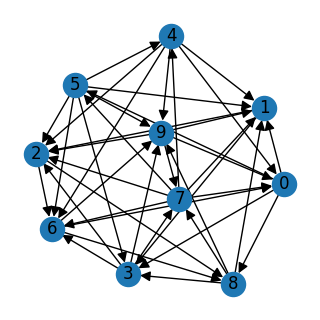

In [4]:
G = nx.DiGraph(J>0)

plt.figure(figsize=[3,3])
nx.draw_kamada_kawai(G, 
                     with_labels=True, 
                     arrowsize=15, 
                    #  arrowstyle="fancy"
                     )

In [12]:
#input powerset
# ps = powerset(matrix_size)

In [13]:
# # dictionary for fp supports
# supports = {}

# # finding fixed points
# for sigma in ps: # index of entry in power set
#     W = np.copy(A) # weight matrix
#     theta = np.ones((matrix_size, 1)) # theta
#     t_s = np.copy(theta) # theta_sigma
#     # print(ps.index(sigma))
#     deac_neur = ps[ps.index(sigma)] #deactivated neurons
#     if sigma:
#         for iter in deac_neur:
#             W[iter-1, :] = 0
#             inverse = np.linalg.inv(np.identity(matrix_size) - W)   
#             t_s[iter-1, :] = 0
#             P = np.round(np.matmul(inverse, t_s), 4)
#         # print(P)
#         checker = check_fp(A, P, theta, t_s)

#     else:
#         inverse = np.linalg.inv(np.identity(matrix_size) - W)
#         P = np.round(np.matmul(inverse, t_s), 4)
#         # print(P)
#         checker = check_fp(A, P, theta, t_s)

#     if np.all(checker) == True:
#         supports[tuple(np.setdiff1d(np.arange(1, matrix_size+1), deac_neur))] = tuple(P)
#         print(stability(W))
    

# # print(supports)
# # print(W_s)
# print(pd.DataFrame.from_dict(supports, orient='index'))

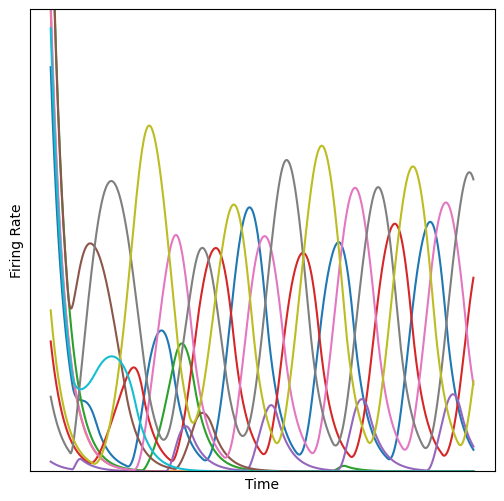

In [9]:
def sys(t, x):
    # x1, x2 = x
    dxdt = (-x + np.maximum(0, A@x + 1))
    return dxdt


x0 = np.random.rand(matrix_size, 1)
time = [0, 30]

x = scp.integrate.solve_ivp(sys, time, x0.flatten(), dense_output=True)
t = np.linspace(0,time[1], 2000)

# plot against time
fig=plt.figure(figsize=(6,6))
plt.plot(t, (x.sol(t)).T)
# print(x.sol)
plt.ylim([0,0.6])

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.xticks([])
plt.yticks([])

# Saving File for Feed-Forward Graphs
# filename1 = 'Graphs and CSVs/Matrix Size ' + str(matrix_size) + ' Symmetry ' + '{:.3f}'.format(symmetry_param)
# i = 0
# while os.path.exists(f"{filename1} {i}.png"):
#     i += 1

# filename2 = 'Graphs and CSVs/Matrix Size ' + str(matrix_size) + ' Symmetry ' + '{:.3f}'.format(symmetry_param)
# i = 0
# while os.path.exists(f"{filename2} {i}.csv"):
#     i += 1

# Saving File for Balanced Graphs
filename1 = 'Graphs and CSVs (Balanced)/Matrix Size ' + str(matrix_size) + ' Symmetry ' + '{:.3f}'.format(symmetry_param) + ' ' + str(p) + ' ' + str(q)
i = 0
while os.path.exists(f"{filename1} {i}.pdf"):
    i += 1

# filename2 = 'Graphs and CSVs (Balanced)/Matrix Size ' + str(matrix_size) + ' Symmetry ' + '{:.3f}'.format(symmetry_param) + ' ' + str(p) + ' ' + str(q)
# i = 0
# while os.path.exists(f"{filename2} {i}.csv"):
#     i += 1

plt.savefig(f"{filename1} {i}.pdf", dpi=720)


# corr_mat = pd.DataFrame(W)
# corr_mat.to_csv(f"{filename2} {i}.csv")

# plot on phase portrait
# plt.xlim([0,1])
# plt.ylim([0,1])
# plot2 = plt.plot(x.sol(t)[0], x.sol(t)[1])
    # i=i+1
plt.show()

(1, 0.0, 0.0, 0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(1, 0.0, 0.0, 0.0)
(0.9, 0.05, 0.05, 0.0)
(0.9, 0.045000000000000005, 0.045000000000000005, 0.010000000000000002)
(0.9, 0.04000000000000001, 0.04000000000000001, 0.020000000000000004)
(0.9, 0.034999999999999996, 0.034999999999999996, 0.03)
(0.9, 0.03, 0.03, 0.04000000000000001)
(0.9, 0.025, 0.025, 0.05)
(0.9, 0.020000000000000004, 0.020000000000000004, 0.06)
(0.9, 0.015000000000000003, 0.015000000000000003, 0.06999999999999999)
(0.9, 0.009999999999999998, 0.009999999999999998, 0.08000000000000002)
(0.9, 0.004999999999999999, 0.004999999999999999, 0.09000000000000001)
(0.9, 0.0, 0.0, 0.1)
(0.8, 0.1, 0.1, 0.0)
(0.8, 0.09000000000000001, 0.09000000000000001, 0.020000000000000004)
(0.8, 0.08000000000000002, 0.08000000000000002, 0.04000000000000001)
(0.8, 0.06999999999999999, 0.06999999999999999, 0.06)
(0.

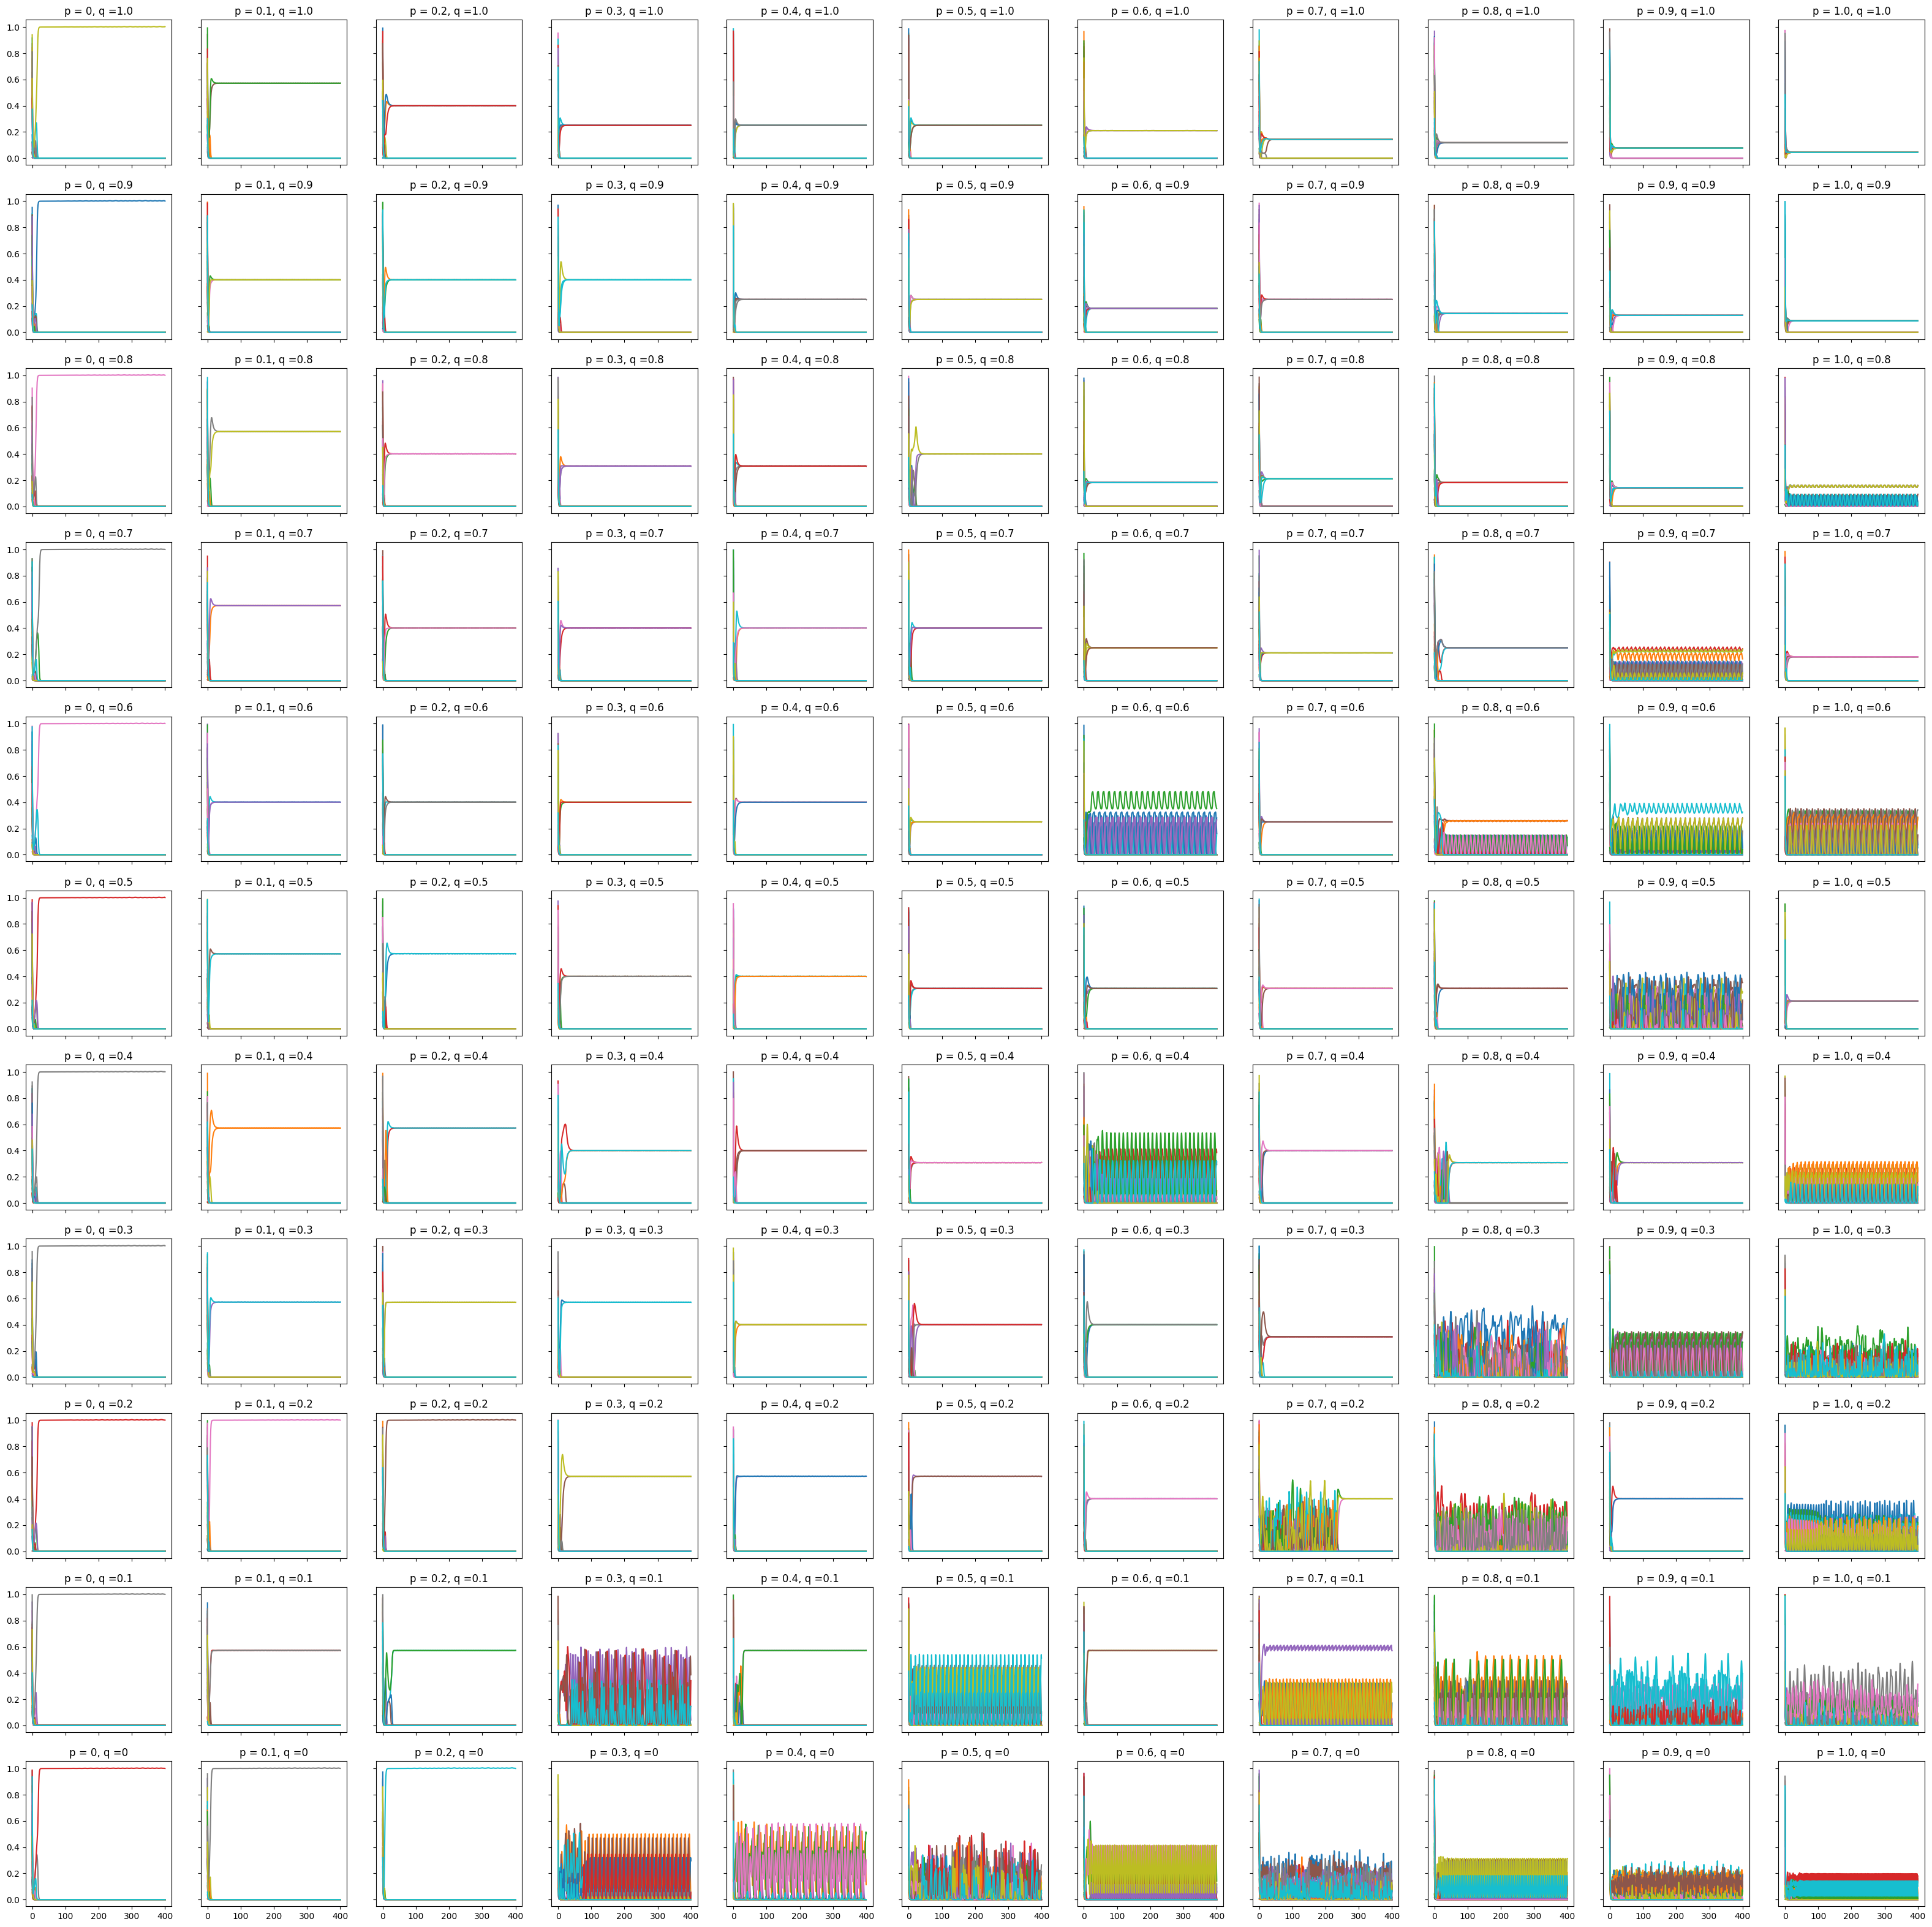

In [14]:
def subplot_gen(mat_size):
    matrix_size = mat_size
    p = 0
    q = 0
    i=0
    fig, axs = plt.subplots(11,11, figsize =(40,40), sharex = True, sharey = True)
    for counter_x in range(0,11):
        q=0
        for counter_y in range(0,11):
            

            # matrix gen
            W = weight_matrix_bal(mat_size,p,q)
            symmetry_param = q
            J = mat_graph(W,mat_size)
            A = np.copy(W)

            # simulating plot
            def sys(t, x):
                dxdt = (-x + np.maximum(0, A@x + 1))
                return dxdt
            x0 = np.random.rand(mat_size, 1)
            time = [0, 400]
            x = scp.integrate.solve_ivp(sys, time, x0.flatten(), dense_output=False)
            # t = np.linspace(0,100, 1001)
            
            # subplot
            u = x.t
            v = (x.y).T
            # fig = plt.figure(1, figsize=(40,40))
            # plt.subplot(11,11,i)
            # plt.plot(u,v)
            # plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[])
            axs[11-(counter_y+1), counter_x].plot(u,v)
            axs[11-(counter_y+1), counter_x].title.set_text("p = {}, q ={}".format(p,q))
            # print(q)
            q += 0.1
            q = round(q,2)
        p += 0.1
        p = round(p,2)
    plt.savefig(f"sample3.pdf")

subplot_gen(30)

subplots for observing dynamics across intervals

fig,axs = plt.subplots
axs[i,j].plot()

take derivative at t_final, tolerance for numerical error, determine if is fixed point or dynamic attractor 
heat map averaged over multiple trials (different matrices and ICs)

In a purely symmetric graph, how many stable fixed points do you expect?
fp corespond to target free cliques
any target free clique is maximal in symmetric graph


p = 0, q = 0, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.1, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.2, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.3, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.4, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.5, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.6, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.7, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.8, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 0.9, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0, q = 1.0, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0.1, q = 0, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0.1, q = 0.1, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0.1, q = 0.2, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0.1, q = 0.3, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0.1, q = 0.4, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0.1, q = 0.5, trial_close = [1, 1, 1, 1, 1], mean = 1
p = 0.1, q = 0.6, trial_close = [1, 1, 1

KeyboardInterrupt: 

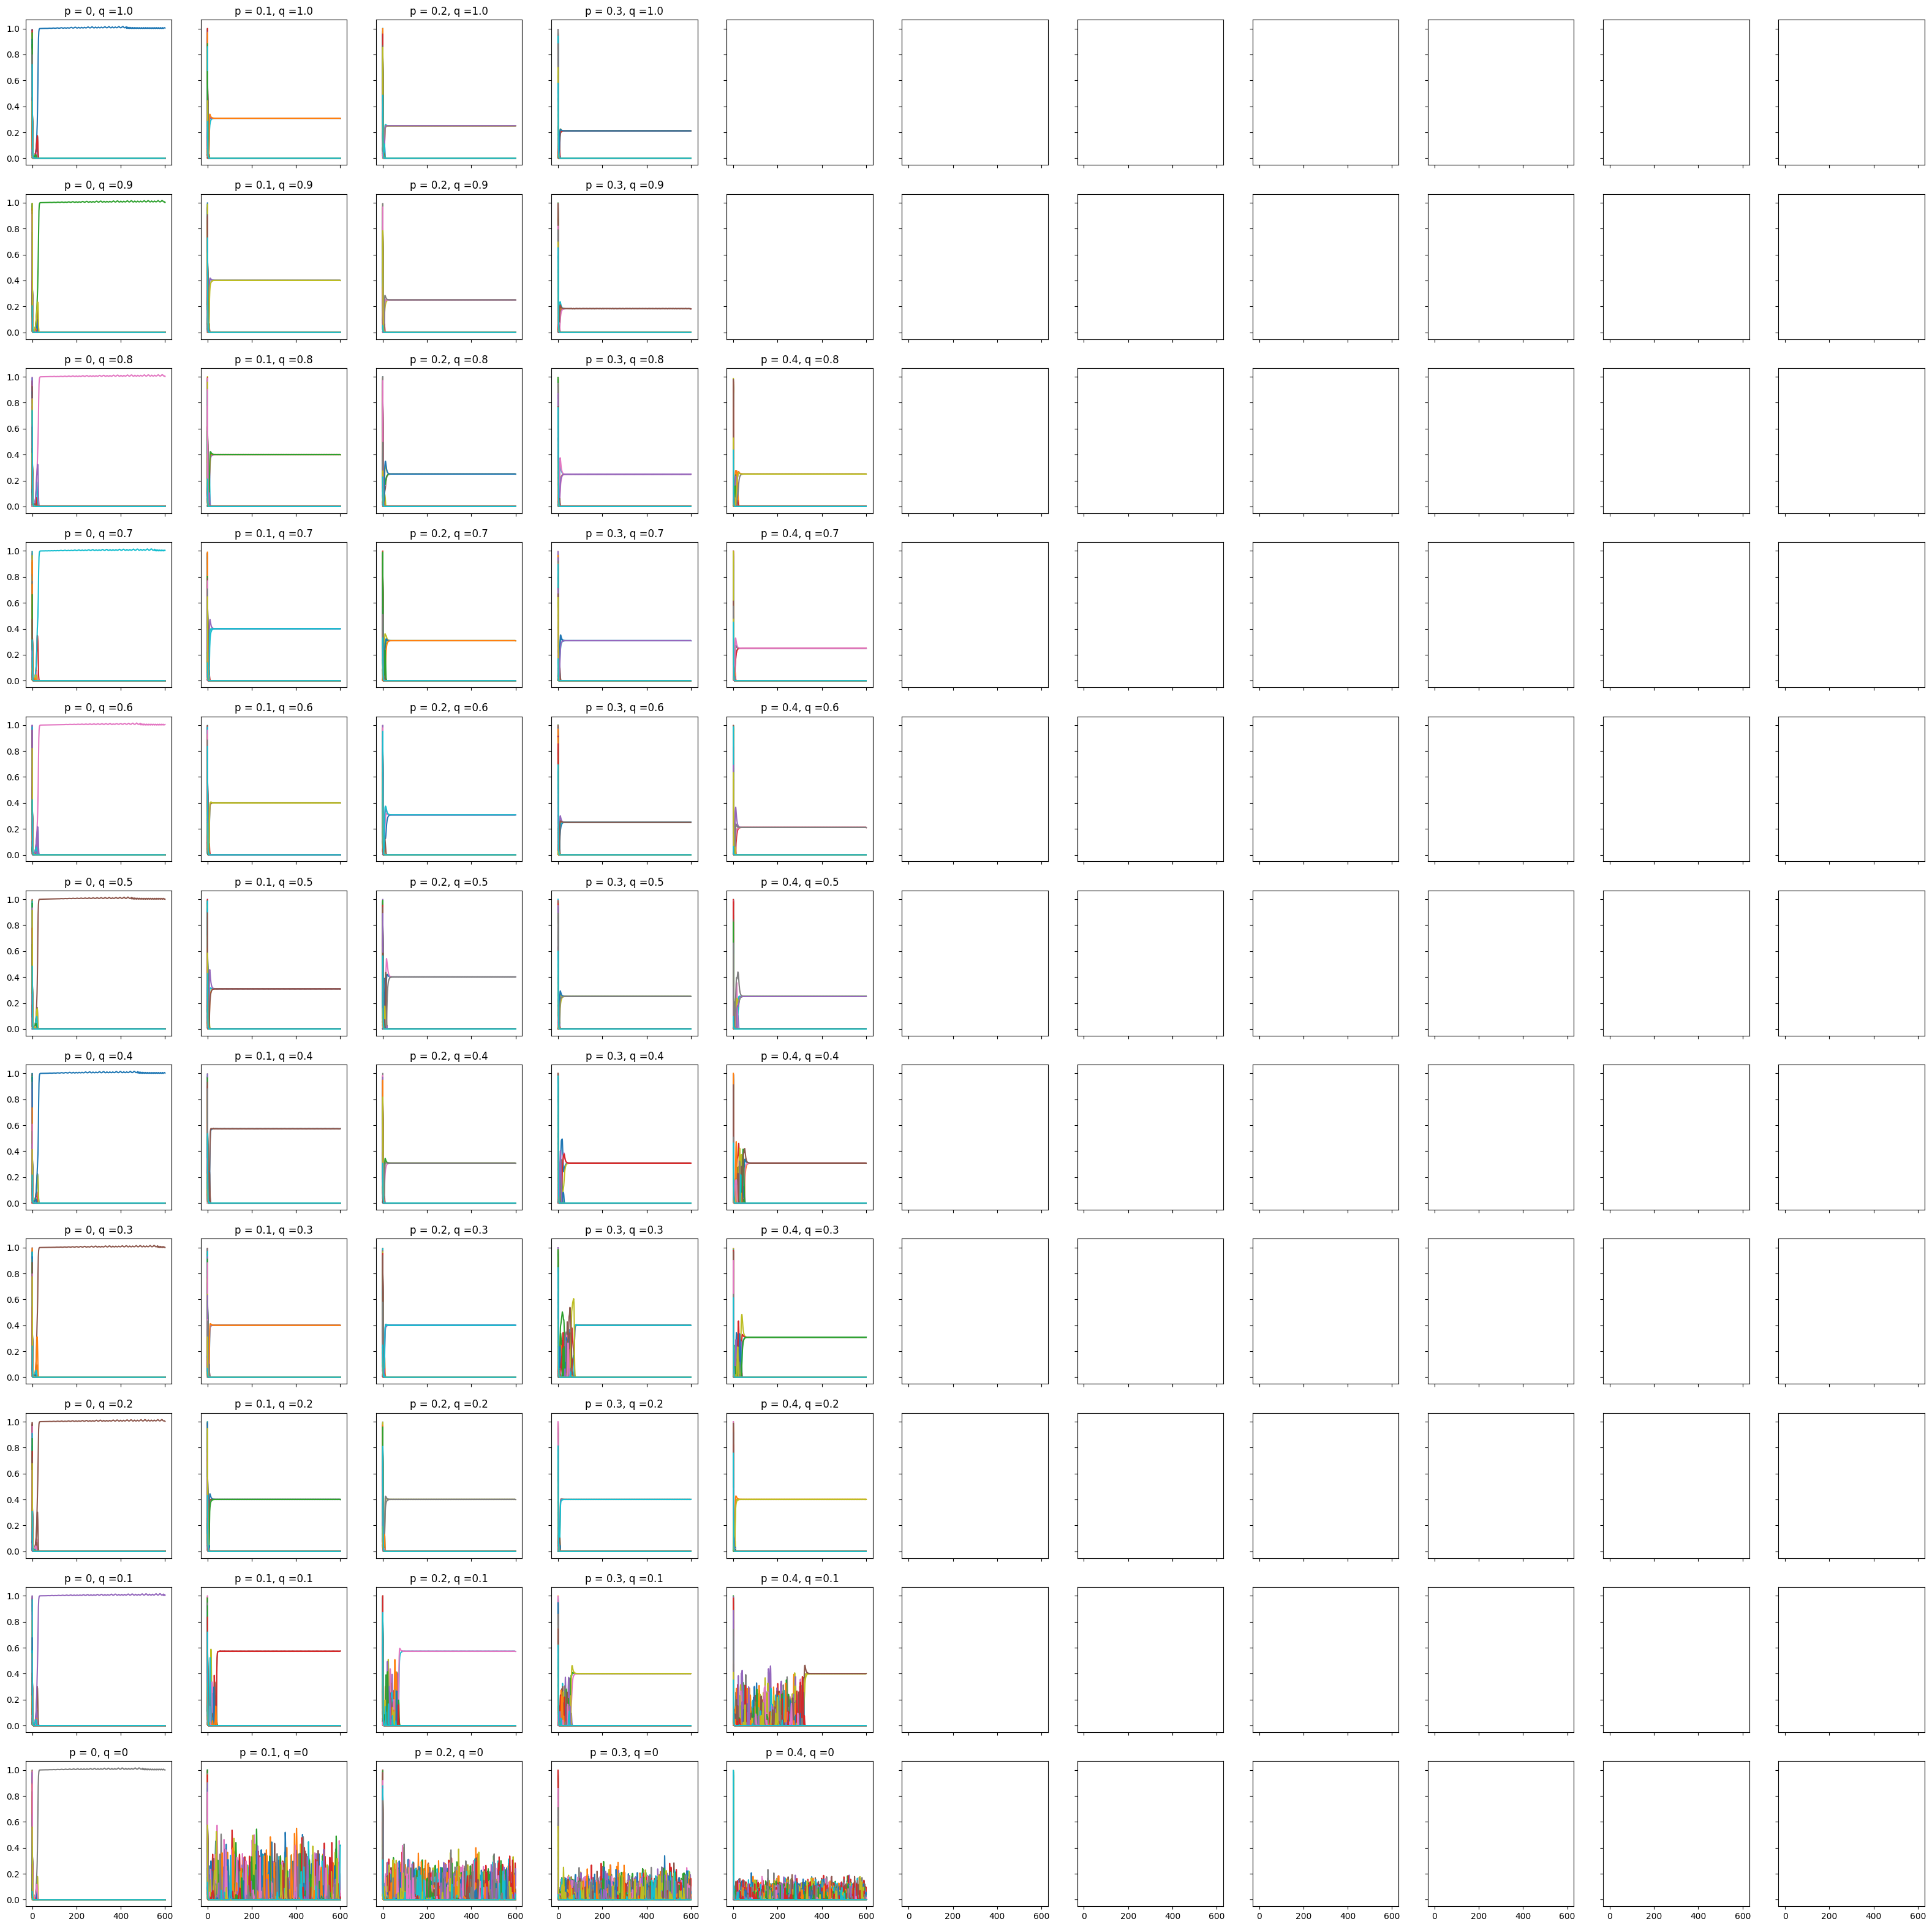

In [10]:
mat_size = 300
param_average = np.zeros((11,11))
p_chart = np.zeros((11,11))
q_chart = np.zeros((11,11))

p = 0
q = 0

fig, axs = plt.subplots(11,11, figsize =(40,40), sharex = True, sharey = True)

for i in range(1):
    p=0
    for counter_x in range(0,11):
        q = 0
        for counter_y in range(0,11):
            trial_close = []
            for i in range(5):
                W = weight_matrix_bal(mat_size,p,q)
                symmetry_param = q
                J = mat_graph(W,mat_size)
                A = np.copy(W)

                def sys(t, x):
                    dxdt = (-x + np.maximum(0, A@x + 1))
                    return dxdt
                
                x0 = np.random.rand(mat_size, 1)
                time = [0, 600]

                sol = scp.integrate.solve_ivp(sys, time, x0.flatten(), dense_output=False)

                # Check for convergence

                for row in sol.y:
                    close = []
                    for entry in range(1,25):
                        if abs(row[-1]-row[-entry]) <= 0.01:
                            close.append(1)
                        else:
                            close.append(0)
                    # print(row)
                if st.mean(close) != 1:
                    trial_close.append(0)
                else:
                    trial_close.append(1)
            param_average[11-(counter_y+1), counter_x] = st.mean(trial_close)
        
            print(f"p = {p}, q = {q}, trial_close = {trial_close}, mean = {st.mean(trial_close)}")

            # print(trial_close)
            # subplot
            u = sol.t
            v = (sol.y).T
            # fig = plt.figure(1, figsize=(40,40))
            # plt.subplot(11,11,i)
            # plt.plot(u,v)
            # plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[])
            axs[11-(counter_y+1), counter_x].plot(u,v)
            axs[11-(counter_y+1), counter_x].title.set_text("p = {}, q ={}".format(p,q))
            # print(p,q)

            p_chart[11-(counter_y+1), counter_x] = p
            p_chart[11-(counter_y+1), counter_x] = q

            q += 0.1
            q = round(q,2)
        p += 0.1
        p = round(p,2)
    # print(param_average)

    fig = plt.figure(figsize=(4,4))
    plt.imshow(param_average, cmap = 'RdYlBu')
    plt.colorbar()
    plt.xlabel('p values')  # Label for x-axis
    plt.ylabel('q values')  # Label for y-axis
    plt.title('Heatmap of Parameters')
    plt.plot()



    # Saving File for Balanced Graphs
    filename1 = 'Heatmaps/Matrix Size ' + str(mat_size) +' new algorithm'
    i = 0
    while os.path.exists(f"{filename1} {i}.png"):
        i += 1

    plt.savefig(f"{filename1} {i}.png", dpi=720)

C:\Users\avalon\AppData\Local\Temp\ipykernel_33456\2712123028.py:15: RuntimeWarning: divide by zero encountered in log
  log_term2 = (N - k) * np.log(1 - (p * q + p * (1 - q) / 2)**k) if (p * q + p * (1 - q) / 2) < 1 else 0
C:\Users\avalon\AppData\Local\Temp\ipykernel_33456\2712123028.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, f_values.max() * 1.1)  # Scale dynamically
C:\Users\avalon\AppData\Local\Temp\ipykernel_33456\2712123028.py:47: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1)  # Keep within reasonable bounds


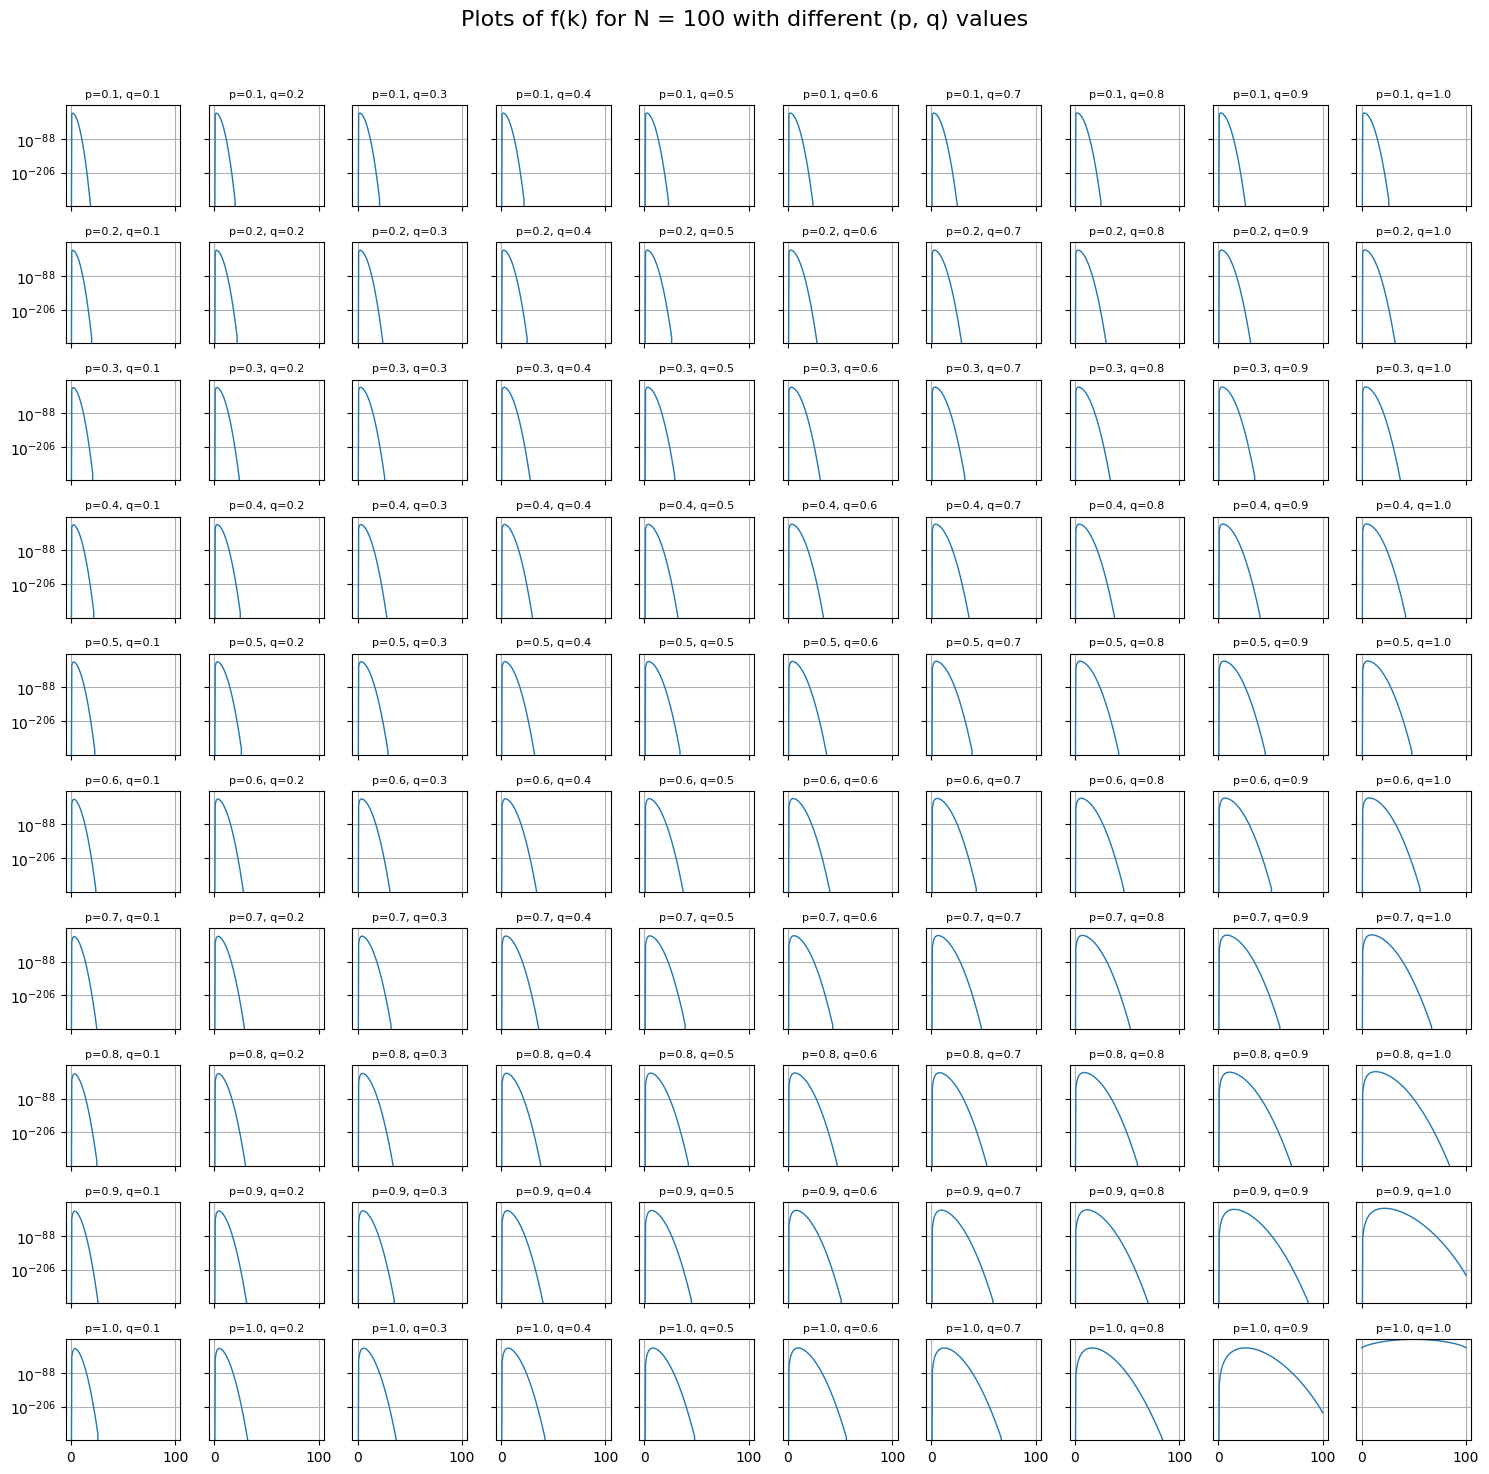

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln

# Log-based binomial coefficient function to prevent overflow
def log_comb(N, k):
    return gammaln(N + 1) - (gammaln(k + 1) + gammaln(N - k + 1))

# Function definition with numerical stability
def f(k, N, p, q):
    if k > N or k < 0:
        return 0
    log_binom = log_comb(N, k)
    log_term1 = np.log(p * q) * (k * (k - 1) / 2) if p * q > 0 else 0
    log_term2 = (N - k) * np.log(1 - (p * q + p * (1 - q) / 2)**k) if (p * q + p * (1 - q) / 2) < 1 else 0
    
    log_f = log_binom + log_term1 + log_term2
    return np.exp(log_f)  # Convert back from log space

# Define p, q grid
p_values = np.arange(0.1, 1.1, 0.1)
q_values = np.arange(0.1, 1.1, 0.1)
N = 100

# Create the grid of subplots
fig, axes = plt.subplots(len(p_values), len(q_values), figsize=(15, 15), sharex=True, sharey=True)
fig.suptitle(f'Plots of f(k) for N = {N} with different (p, q) values', fontsize=16)

for i, p in enumerate(p_values):
    for j, q in enumerate(q_values):
        ax = axes[i, j]
        k_values = np.arange(0, N + 1)
        f_values = np.array([f(k, N, p, q) for k in k_values])

        # If values explode, use log scale
        if f_values.max() > 1000:
            ax.set_yscale('log')

        ax.plot(k_values, f_values, lw=1)
        ax.set_title(f"p={p:.1f}, q={q:.1f}", fontsize=8)
        ax.grid(True)

        # Set adaptive y-limits
        if f_values.max() > 1:
            ax.set_ylim(0, f_values.max() * 1.1)  # Scale dynamically
        else:
            ax.set_ylim(0, 1)  # Keep within reasonable bounds

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


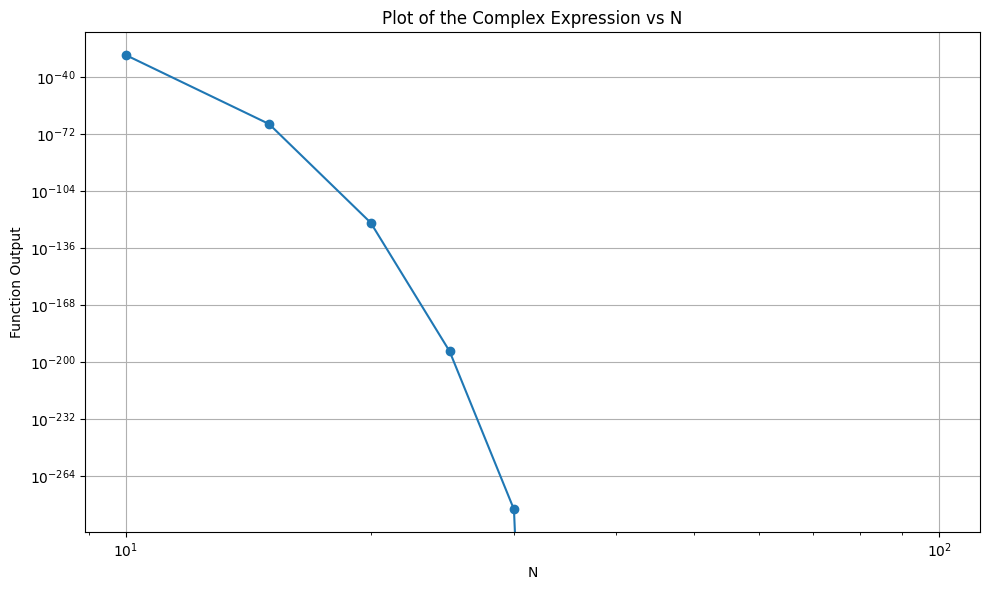

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

# Constants
p = 0.9
q = 0.1
alpha = 0.8

# Function to compute the expression
def complex_expression(N):
    N = np.array(N, dtype=np.float64)
    
    # Stirling approximations
    A = np.sqrt(2 * np.pi * N) * (N / np.e) ** N
    B = np.sqrt(2 * np.pi * alpha * N) * ((alpha * N) / np.e) ** (alpha * N)
    C = np.sqrt(2 * np.pi * N * (1 - alpha)) * ((N * (1 - alpha)) / np.e) ** (N * (1 - alpha))
    
    prefactor = A / (B * C)
    
    power_term = (p * q) ** (alpha * N * (alpha * N - 1) / 2)
    inner_term = p * (1 - q) / 2 + p * q
    bracket_term = (1 - inner_term ** (alpha * N)) ** (N * (1 - alpha))
    
    return prefactor * power_term * bracket_term

# Range of N values
N_values = np.arange(10, 101, 5)
outputs = complex_expression(N_values)

# Plotting
plt.figure(figsize=(10, 6))
plt.loglog(N_values, outputs, marker='o')
plt.xlabel('N')
plt.ylabel('Function Output')
plt.title('Plot of the Complex Expression vs N')
plt.grid(True)
plt.tight_layout()
plt.show()


Starting simulation...
p=0.0, q=0.0 | Mean Convergence: 1.00
p=0.0, q=0.1 | Mean Convergence: 1.00
p=0.0, q=0.2 | Mean Convergence: 1.00
p=0.0, q=0.3 | Mean Convergence: 1.00
p=0.0, q=0.4 | Mean Convergence: 1.00
p=0.0, q=0.5 | Mean Convergence: 1.00
p=0.0, q=0.6 | Mean Convergence: 1.00
p=0.0, q=0.7 | Mean Convergence: 1.00
p=0.0, q=0.8 | Mean Convergence: 1.00
p=0.0, q=0.9 | Mean Convergence: 1.00
p=0.0, q=1.0 | Mean Convergence: 1.00
p=0.1, q=0.0 | Mean Convergence: 0.38
p=0.1, q=0.1 | Mean Convergence: 0.94
p=0.1, q=0.2 | Mean Convergence: 0.96
p=0.1, q=0.3 | Mean Convergence: 0.98
p=0.1, q=0.4 | Mean Convergence: 1.00
p=0.1, q=0.5 | Mean Convergence: 1.00
p=0.1, q=0.6 | Mean Convergence: 1.00
p=0.1, q=0.7 | Mean Convergence: 1.00
p=0.1, q=0.8 | Mean Convergence: 1.00
p=0.1, q=0.9 | Mean Convergence: 1.00
p=0.1, q=1.0 | Mean Convergence: 1.00
p=0.2, q=0.0 | Mean Convergence: 0.04
p=0.2, q=0.1 | Mean Convergence: 0.98
p=0.2, q=0.2 | Mean Convergence: 0.94
p=0.2, q=0.3 | Mean Converg

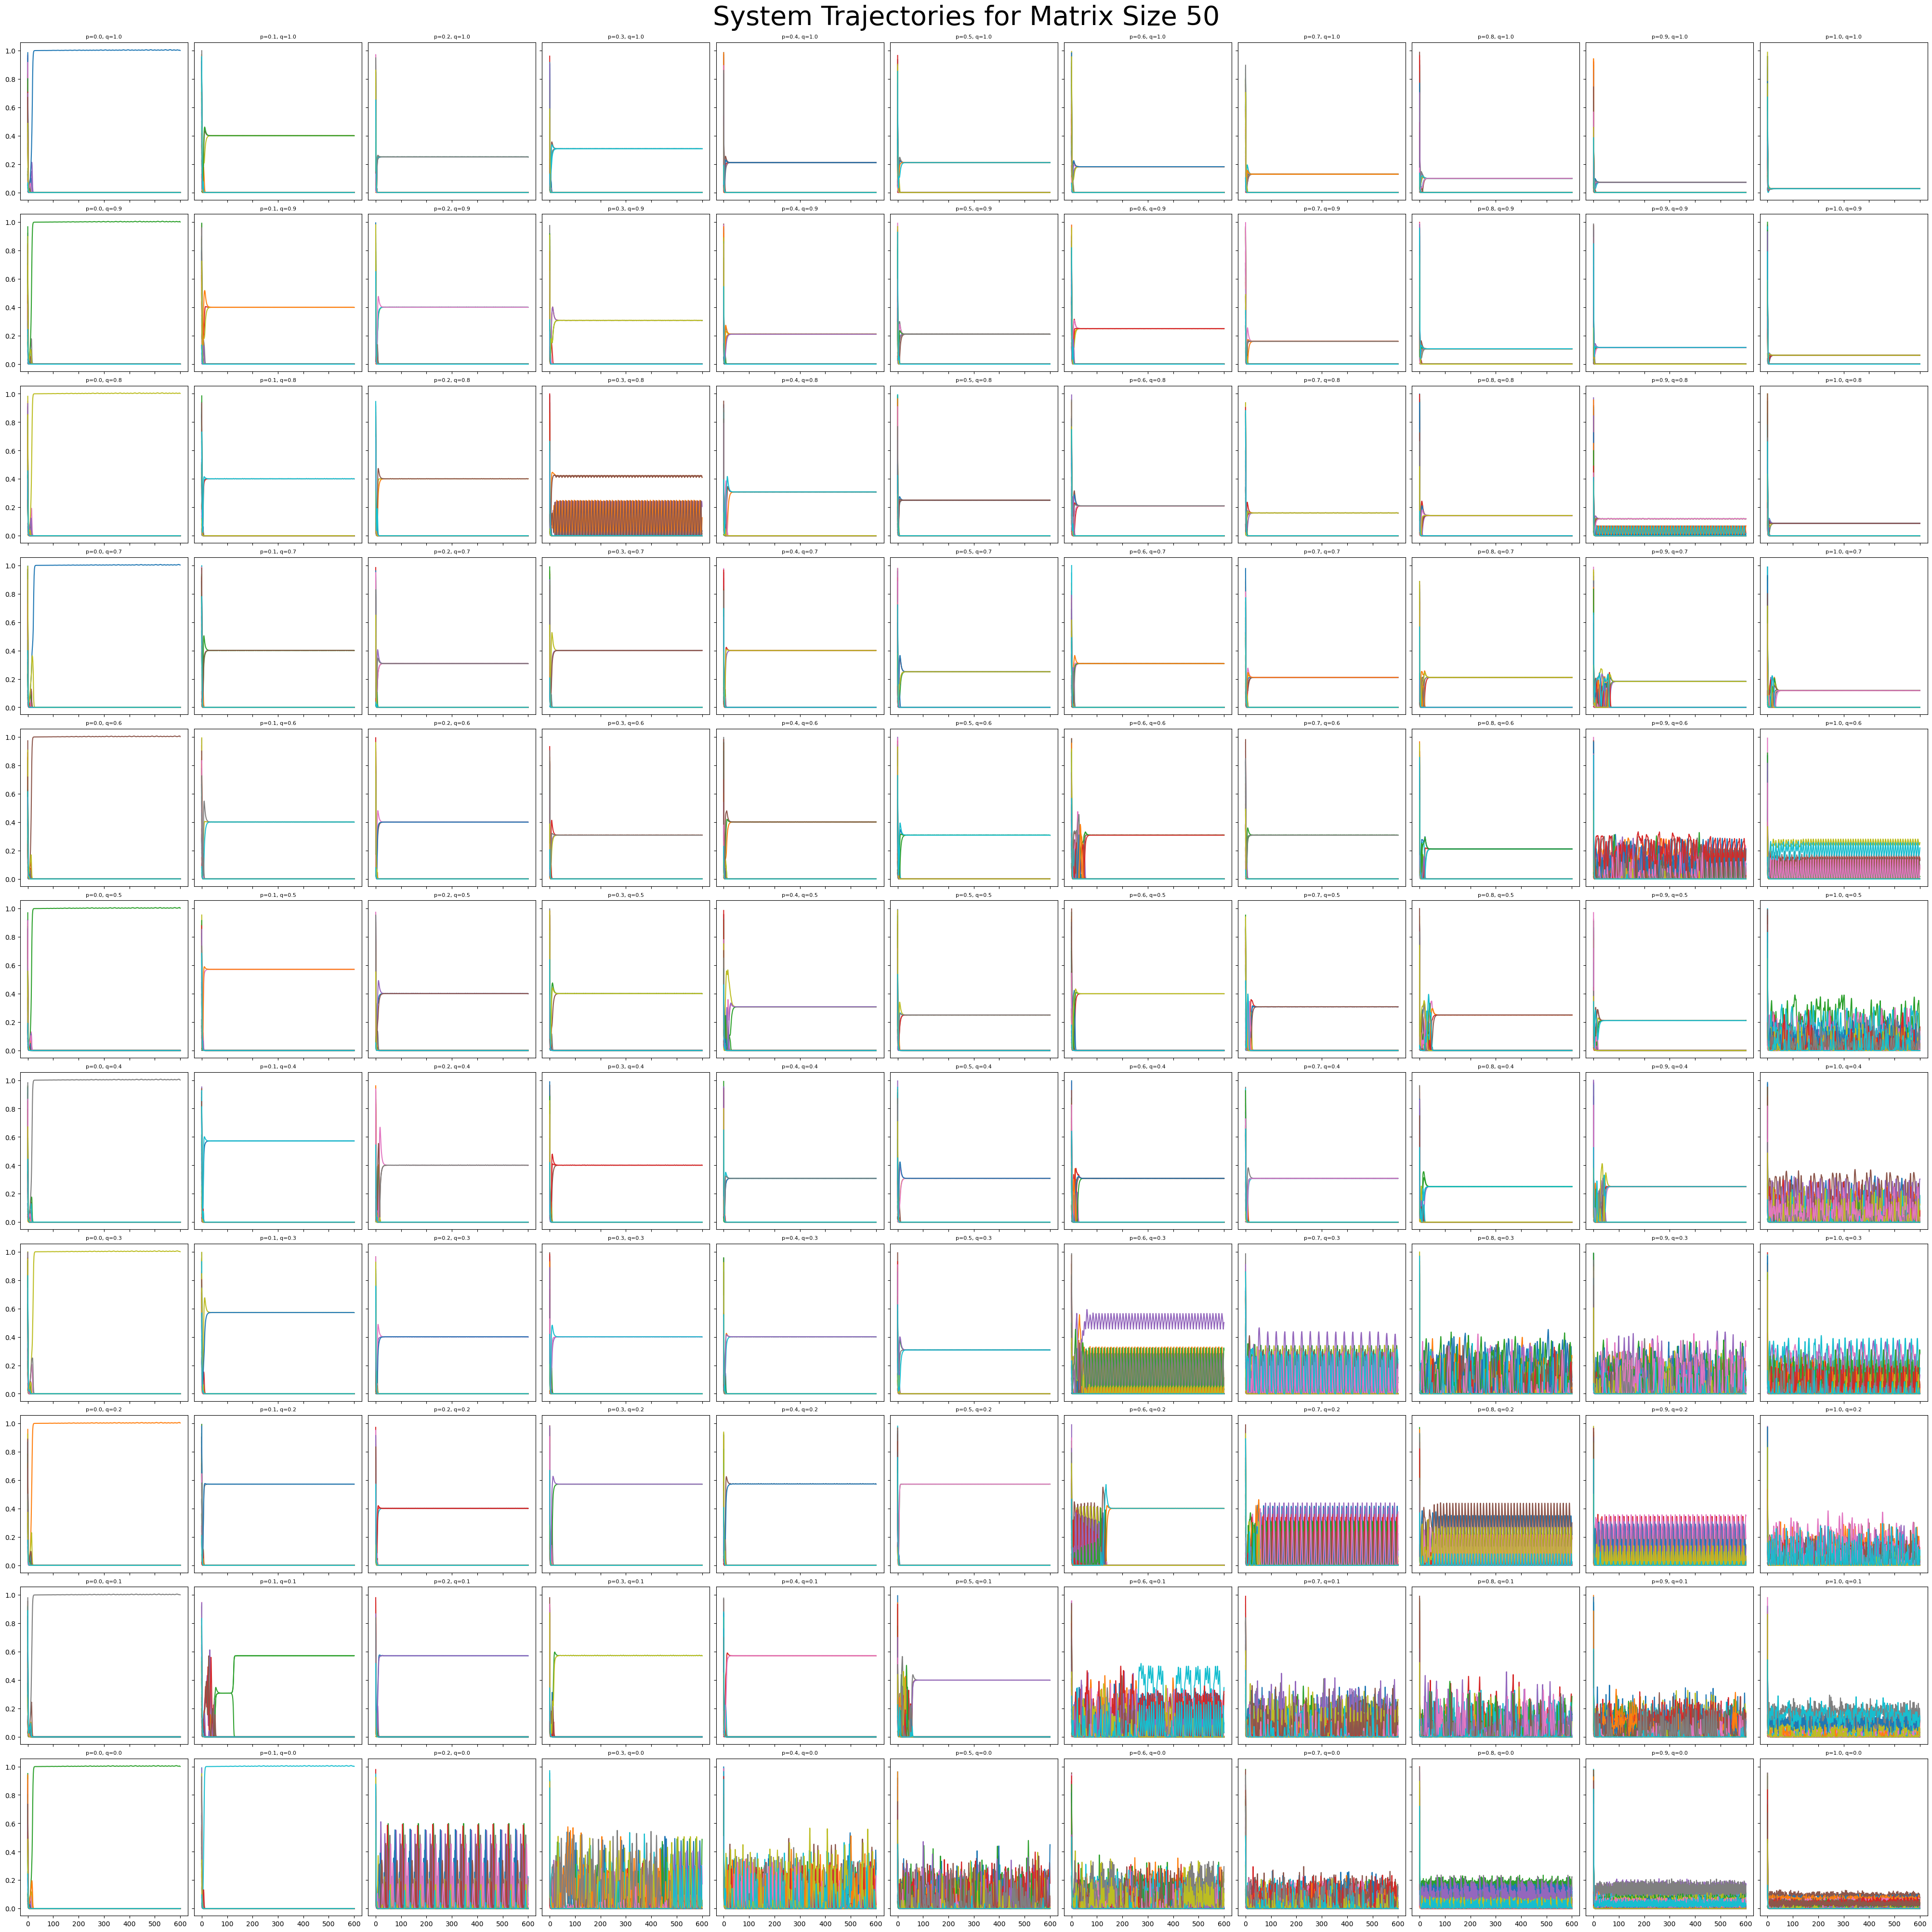

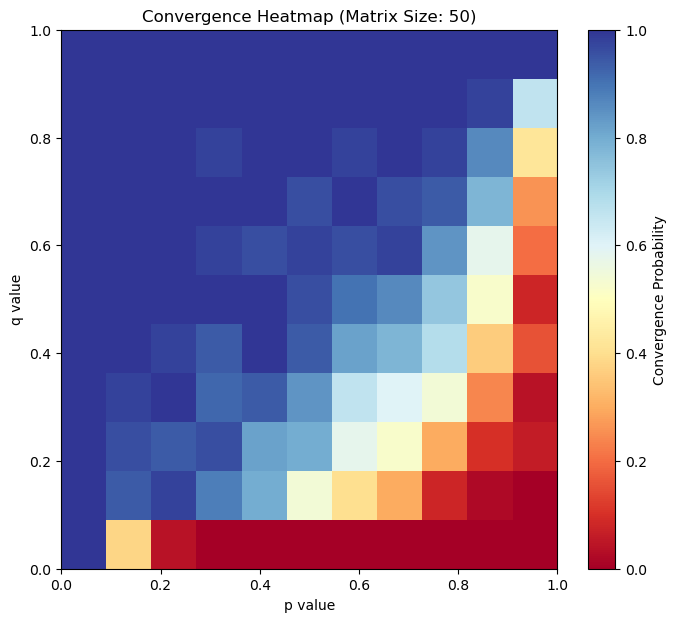

In [ ]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
import os

# ===================================================================
#                          PARAMETERS
# ===================================================================
# Model parameters
E_PARAM = 0.25  # Epsilon
D_PARAM = 0.5   # Delta

# Simulation parameters
MATRIX_SIZE = 50
P_VALS = np.linspace(0, 1, 11)
Q_VALS = np.linspace(0, 1, 11)
NUM_TRIALS = 50  # Number of runs for each (p,q) pair

# ODE solver and convergence check parameters
TIME_SPAN = [0, 600]
CONVERGENCE_WINDOW = 25  # How many recent time steps to check for convergence
CONVERGENCE_TOL = 0.01   # Tolerance for checking if values are stable

# ===================================================================
#                        OPTIMIZED FUNCTIONS
# ===================================================================

def generate_weight_matrix(matrix_size, p, q):
    """
    Generates a weight matrix using a fully vectorized approach for efficiency.
    
    This function avoids Python loops by generating all random choices for the
    upper triangle of the matrix at once and then using NumPy's boolean
    masking to apply the weight rules based on the model's parameters.
    """
    # Probabilities for choosing one of the four interaction types
    weights = [1 - p, p * (1 - q) / 2, p * (1 - q) / 2, p * q]
    possible_vals = np.array([-2, -1, 1, 2])

    # Get indices for the upper triangle of the matrix (where i < j)
    i_upper, j_upper = np.triu_indices(matrix_size, k=1)
    n_upper = len(i_upper)

    # Make all random choices for the upper triangle in one vectorized call
    choices = np.random.choice(possible_vals, size=n_upper, p=weights)

    # Pre-calculate weight values from parameters
    w_excited = -1 + E_PARAM
    # --- BUG FIX IS HERE ---
    # The inhibitory weight must be -1 MINUS delta, not PLUS.
    w_inhibited = -1 - D_PARAM

    # Initialize the final weight matrix
    mat = np.zeros((matrix_size, matrix_size))
    
    # Create arrays to hold the values for W_ij and W_ji
    vals_ij = np.zeros(n_upper)
    vals_ji = np.zeros(n_upper)

    # Apply rules using boolean masks for vectorization. This is much faster than loops.
    # Case 1: Symmetric Excitation (i excites j, j excites i)
    mask_2 = (choices == 2)
    vals_ij[mask_2] = w_excited
    vals_ji[mask_2] = w_excited

    # Case 2: Symmetric Inhibition (i inhibits j, j inhibits i)
    mask_neg2 = (choices == -2)
    vals_ij[mask_neg2] = w_inhibited
    vals_ji[mask_neg2] = w_inhibited

    # Case 3: Asymmetric (i inhibits j, j excites i)
    mask_neg1 = (choices == -1)
    vals_ij[mask_neg1] = w_inhibited
    vals_ji[mask_neg1] = w_excited

    # Case 4: Asymmetric (i excites j, j inhibits i)
    mask_1 = (choices == 1)
    vals_ij[mask_1] = w_excited
    vals_ji[mask_1] = w_inhibited

    # Assign the calculated values to the matrix's upper and lower triangles
    mat[i_upper, j_upper] = vals_ij
    mat[j_upper, i_upper] = vals_ji

    return mat

def system_ode(t, x, W):
    """The system of differential equations to be solved."""
    return -x + np.maximum(0, W @ x + 1)

# ===================================================================
#                           MAIN SCRIPT
# ===================================================================

# --- Setup ---
num_p = len(P_VALS)
num_q = len(Q_VALS)
convergence_heatmap = np.zeros((num_q, num_p))

# Create a figure for the time-series trajectories
fig_trajectories, axs = plt.subplots(num_q, num_p, figsize=(40, 40), 
                                     sharex=True, sharey=True,
                                     constrained_layout=True)
fig_trajectories.suptitle(f'System Trajectories for Matrix Size {MATRIX_SIZE}', fontsize=40)

print("Starting simulation...")

# --- Simulation Loop ---
for p_idx, p in enumerate(P_VALS):
    for q_idx, q in enumerate(Q_VALS):
        trial_convergence_results = []
        
        # Run several trials for statistical robustness
        for trial_num in range(NUM_TRIALS):
            W = generate_weight_matrix(MATRIX_SIZE, p, q)
            x0 = np.random.rand(MATRIX_SIZE) # Random initial conditions

            # Solve the ODE
            sol = scipy.integrate.solve_ivp(
                lambda t, x: system_ode(t, x, W), 
                TIME_SPAN, 
                x0
            )

            

            # --- Vectorized Convergence Check ---
            is_converged = False
            # Ensure there are enough data points to check
            if sol.y.shape[1] >= CONVERGENCE_WINDOW:
                final_values = sol.y[:, -1, np.newaxis]
                recent_points = sol.y[:, -CONVERGENCE_WINDOW:]
                if np.all(np.abs(final_values - recent_points) <= CONVERGENCE_TOL):
                    is_converged = True
            
            trial_convergence_results.append(1 if is_converged else 0)

        # Store the average convergence rate for this (p, q) pair
        convergence_heatmap[q_idx, p_idx] = np.mean(trial_convergence_results)
        print(f"p={p:.1f}, q={q:.1f} | Mean Convergence: {np.mean(trial_convergence_results):.2f}")

        # Plot trajectories on the correct subplot
        ax = axs[num_q - 1 - q_idx, p_idx]
        ax.plot(sol.t, sol.y.T)
        ax.set_title(f"p={p:.1f}, q={q:.1f}", fontsize=8)

print("\nSimulation complete. Generating heatmap...")

# --- Visualization ---
fig_heatmap, ax_heatmap = plt.subplots(figsize=(8, 7))
im = ax_heatmap.imshow(convergence_heatmap, cmap='RdYlBu', origin='lower',
                        extent=[P_VALS.min(), P_VALS.max(), Q_VALS.min(), Q_VALS.max()],
                        aspect='auto')

fig_heatmap.colorbar(im, ax=ax_heatmap, label='Convergence Probability')
ax_heatmap.set_xlabel('p value')
ax_heatmap.set_ylabel('q value')
ax_heatmap.set_title(f'Convergence Heatmap (Matrix Size: {MATRIX_SIZE})')

# --- Save Figures ---
output_dir = 'Heatmaps'
os.makedirs(output_dir, exist_ok=True)

i = 0
while True:
    base_filename = f'MatrixSize_{MATRIX_SIZE}_Run_{i}'
    heatmap_path = os.path.join(output_dir, f"{base_filename}_heatmap.pdf")
    if not os.path.exists(heatmap_path):
        break
    i += 1

fig_heatmap.savefig(heatmap_path, dpi=300, bbox_inches='tight')
print(f"Heatmap saved to {heatmap_path}")

trajectories_path = os.path.join(output_dir, f"{base_filename}_trajectories.pdf")
fig_trajectories.savefig(trajectories_path, dpi=150)
print(f"Trajectories plot saved to {trajectories_path}")

plt.show()


In [ ]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
import os
import itertools
from multiprocessing import Pool, cpu_count
# Tqdm is no longer needed for the pool.map implementation
# from tqdm import tqdm

# ===================================================================
#                          PARAMETERS
# ===================================================================
# Model parameters
E_PARAM = 0.25  # Epsilon
D_PARAM = 0.5   # Delta

# Simulation parameters
MATRIX_SIZE = 30
P_VALS = np.linspace(0, 1, 11)
Q_VALS = np.linspace(0, 1, 11)
NUM_TRIALS = 5  # Number of runs for each (p,q) pair

# ODE solver and convergence check parameters
TIME_SPAN = [0, 600]
CONVERGENCE_WINDOW = 25
CONVERGENCE_TOL = 0.01

# Multiprocessing parameters
# Uses one less than the total number of cores by default to keep the system responsive.
# For a 6-core CPU, this will default to 5. You can manually set this to another number.
NUM_PROCESSES = max(1, cpu_count() - 1)

# ===================================================================
#                 CORE FUNCTIONS (Unchanged)
# ===================================================================

def generate_weight_matrix(matrix_size, p, q):
    """Generates a weight matrix using a fully vectorized approach."""
    weights = [1 - p, p * (1 - q) / 2, p * (1 - q) / 2, p * q]
    possible_vals = np.array([-2, -1, 1, 2])
    i_upper, j_upper = np.triu_indices(matrix_size, k=1)
    n_upper = len(i_upper)
    choices = np.random.choice(possible_vals, size=n_upper, p=weights)

    w_excited = -1 + E_PARAM
    w_inhibited = -1 - D_PARAM # Corrected inhibitory weight

    mat = np.zeros((matrix_size, matrix_size))
    vals_ij, vals_ji = np.zeros(n_upper), np.zeros(n_upper)

    vals_ij[choices == 2], vals_ji[choices == 2] = w_excited, w_excited
    vals_ij[choices == -2], vals_ji[choices == -2] = w_inhibited, w_inhibited
    vals_ij[choices == -1], vals_ji[choices == -1] = w_inhibited, w_excited
    vals_ij[choices == 1], vals_ji[choices == 1] = w_excited, w_inhibited

    mat[i_upper, j_upper], mat[j_upper, i_upper] = vals_ij, vals_ji
    return mat

def system_ode(t, x, W):
    """The system of differential equations to be solved."""
    return -x + np.maximum(0, W @ x + 1)

# ===================================================================
#                        PARALLEL WORKER FUNCTION
# ===================================================================

def run_simulation_for_pair(params):
    """
    This is the "worker" function. It runs all trials for a single (p, q) pair
    and returns the mean convergence rate.
    """
    p, q = params  # Unpack the parameters
    # DEBUG: Announce that a worker has started a specific task.
    print(f"DEBUG: Worker PID {os.getpid()} starting task for p={p:.1f}, q={q:.1f}")
    
    trial_convergence_results = []
    
    for trial_num in range(NUM_TRIALS):
        W = generate_weight_matrix(MATRIX_SIZE, p, q)
        x0 = np.random.rand(MATRIX_SIZE)
        
        sol = scipy.integrate.solve_ivp(
            system_ode, 
            TIME_SPAN, 
            x0,
            args=(W,) 
        )

        is_converged = False
        if sol.y.shape[1] >= CONVERGENCE_WINDOW:
            final_values = sol.y[:, -1, np.newaxis]
            recent_points = sol.y[:, -CONVERGENCE_WINDOW:]
            if np.all(np.abs(final_values - recent_points) <= CONVERGENCE_TOL):
                is_converged = True
        trial_convergence_results.append(1 if is_converged else 0)
        
    # DEBUG: Announce that a worker has completed a task.
    print(f"DEBUG: Worker PID {os.getpid()} finished task for p={p:.1f}, q={q:.1f}")
    return np.mean(trial_convergence_results)

# ===================================================================
#                           MAIN SCRIPT
# ===================================================================

def main():
    """Main execution block."""
    print("DEBUG: main() function started.")
    num_p = len(P_VALS)
    num_q = len(Q_VALS)

    # 1. Create a list of all (p, q) pairs to simulate
    param_grid = list(itertools.product(P_VALS, Q_VALS))
    print(f"DEBUG: Created parameter grid with {len(param_grid)} tasks.")

    # 2. Set up the multiprocessing Pool
    print(f"Starting simulation on {NUM_PROCESSES} CPU cores...")

    results = []
    with Pool(processes=NUM_PROCESSES) as pool:
        print("DEBUG: Multiprocessing pool created.")
        print("DEBUG: Calling pool.map(). The script will now block until all tasks are complete.")
        # The 'map' function will block until all tasks in param_grid are complete.
        results = pool.map(run_simulation_for_pair, param_grid)
        
    print("\nDEBUG: pool.map() has completed. All workers finished.")
    print(f"DEBUG: Received {len(results)} results from workers.")

    # 4. Reshape the flat list of results back into a 2D grid for the heatmap
    convergence_heatmap = np.array(results).reshape(num_p, num_q).T
    print("DEBUG: Reshaped results into the heatmap array.")

    print("\nSimulation complete. Generating heatmap...")

    # --- Visualization ---
    fig_heatmap, ax_heatmap = plt.subplots(figsize=(8, 7))
    im = ax_heatmap.imshow(convergence_heatmap, cmap='RdYlBu', origin='lower',
                           extent=[P_VALS.min(), P_VALS.max(), Q_VALS.min(), Q_VALS.max()],
                           aspect='auto')
    fig_heatmap.colorbar(im, ax=ax_heatmap, label='Mean Convergence Rate')
    ax_heatmap.set_xlabel('p value')
    ax_heatmap.set_ylabel('q value')
    ax_heatmap.set_title(f'Convergence Heatmap (Matrix Size: {MATRIX_SIZE})')
    print("DEBUG: Plot generated.")

    # --- Save Figure ---
    output_dir = 'Heatmaps'
    os.makedirs(output_dir, exist_ok=True)
    i = 0
    while True:
        heatmap_path = os.path.join(output_dir, f"MatrixSize_{MATRIX_SIZE}_Run_{i}_heatmap.png")
        if not os.path.exists(heatmap_path):
            break
        i += 1
    fig_heatmap.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"DEBUG: Figure saved to {heatmap_path}")
    plt.show()

# This "if __name__ == '__main__':" guard is essential for multiprocessing
if __name__ == '__main__':
    main()



DEBUG: main() function started.
DEBUG: Created parameter grid with 121 tasks.
Starting simulation on 11 CPU cores...
DEBUG: Multiprocessing pool created.
DEBUG: Calling pool.map(). The script will now block until all tasks are complete.


In [3]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
import os

# ===================================================================
#                          PARAMETERS
# ===================================================================
# Model parameters
E_PARAM = 0.25  # Epsilon
D_PARAM = 0.5   # Delta

# Simulation parameters
MATRIX_SIZE = 50
P_VALS = np.linspace(0, 1, 11)
Q_VALS = np.linspace(0, 1, 11)
NUM_TRIALS = 2 # Number of runs for each (p,q) pair

# ODE solver and convergence check parameters
TIME_SPAN = [0, 600]
CONVERGENCE_WINDOW = 25  # How many recent time steps to check for convergence
CONVERGENCE_TOL = 0.01   # Tolerance for checking if values are stable

# ===================================================================
#                        OPTIMIZED FUNCTIONS
# ===================================================================

def generate_weight_matrix(matrix_size, p, q):
    """
    Generates a weight matrix using a fully vectorized approach for efficiency.
    
    This function avoids Python loops by generating all random choices for the
    upper triangle of the matrix at once and then using NumPy's boolean
    masking to apply the weight rules based on the model's parameters.
    """
    # Probabilities for choosing one of the four interaction types
    weights = [1 - p, p * (1 - q) / 2, p * (1 - q) / 2, p * q]
    possible_vals = np.array([-2, -1, 1, 2])

    # Get indices for the upper triangle of the matrix (where i < j)
    i_upper, j_upper = np.triu_indices(matrix_size, k=1)
    n_upper = len(i_upper)

    # Make all random choices for the upper triangle in one vectorized call
    choices = np.random.choice(possible_vals, size=n_upper, p=weights)

    # Pre-calculate weight values from parameters
    w_excited = -1 + E_PARAM
    # --- BUG FIX IS HERE ---
    # The inhibitory weight must be -1 MINUS delta, not PLUS.
    w_inhibited = -1 - D_PARAM

    # Initialize the final weight matrix
    mat = np.zeros((matrix_size, matrix_size))
    
    # Create arrays to hold the values for W_ij and W_ji
    vals_ij = np.zeros(n_upper)
    vals_ji = np.zeros(n_upper)

    # Apply rules using boolean masks for vectorization. This is much faster than loops.
    # Case 1: Symmetric Excitation (i excites j, j excites i)
    mask_2 = (choices == 2)
    vals_ij[mask_2] = w_excited
    vals_ji[mask_2] = w_excited

    # Case 2: Symmetric Inhibition (i inhibits j, j inhibits i)
    mask_neg2 = (choices == -2)
    vals_ij[mask_neg2] = w_inhibited
    vals_ji[mask_neg2] = w_inhibited

    # Case 3: Asymmetric (i inhibits j, j excites i)
    mask_neg1 = (choices == -1)
    vals_ij[mask_neg1] = w_inhibited
    vals_ji[mask_neg1] = w_excited

    # Case 4: Asymmetric (i excites j, j inhibits i)
    mask_1 = (choices == 1)
    vals_ij[mask_1] = w_excited
    vals_ji[mask_1] = w_inhibited

    # Assign the calculated values to the matrix's upper and lower triangles
    mat[i_upper, j_upper] = vals_ij
    mat[j_upper, i_upper] = vals_ji

    return mat

def system_ode(t, x, W):
    """The system of differential equations to be solved."""
    return -x + np.maximum(0, W @ x + 1)

# ===================================================================
#                          MAIN SCRIPT
# ===================================================================

print("Starting trajectory generation...")

# --- Setup for saving trajectory plots ---
output_dir = 'Trajectory Generation'
os.makedirs(output_dir, exist_ok=True)

# --- Simulation Loop ---
for p_idx, p in enumerate(P_VALS):
    for q_idx, q in enumerate(Q_VALS):
        # Run several trials for statistical robustness
        for trial_num in range(NUM_TRIALS):
            W = generate_weight_matrix(MATRIX_SIZE, p, q)
            x0 = np.random.rand(MATRIX_SIZE) # Random initial conditions

            # Solve the ODE
            sol = scipy.integrate.solve_ivp(
                lambda t, x: system_ode(t, x, W), 
                TIME_SPAN, 
                x0
            )

            # --- Plot and save the individual trajectory ---
            # Create a new figure for each plot to prevent memory issues
            fig, ax = plt.subplots(figsize=(12, 8))
            ax.plot(sol.t, sol.y.T)
            ax.set_title(f"Trajectory Plot for p={p:.2f}, q={q:.2f}, Trial {trial_num+1}", fontsize=14)
            ax.set_xlabel("Time (t)")
            ax.set_ylabel("x(t)")
            ax.grid(True, linestyle='--', alpha=0.6)

            # Define a unique filename for each plot
            filename = f"trajectories_p{p_idx:02d}_q{q_idx:02d}_trial{trial_num:02d}.png"
            filepath = os.path.join(output_dir, filename)

            # Save the figure
            fig.savefig(filepath, dpi=300, bbox_inches='tight')
            
            # Close the figure to free up memory
            plt.close(fig)

            print(f"p={p:.2f}, q={q:.2f}, Trial {trial_num+1} | Saved to: {filepath}")

print("\nAll trajectory plots have been generated and saved.")

# Note: plt.show() is not called here as all figures are saved and closed.


Starting trajectory generation...
p=0.00, q=0.00, Trial 1 | Saved to: Trajectory Generation\trajectories_p00_q00_trial00.png
p=0.00, q=0.00, Trial 2 | Saved to: Trajectory Generation\trajectories_p00_q00_trial01.png
p=0.00, q=0.10, Trial 1 | Saved to: Trajectory Generation\trajectories_p00_q01_trial00.png
p=0.00, q=0.10, Trial 2 | Saved to: Trajectory Generation\trajectories_p00_q01_trial01.png
p=0.00, q=0.20, Trial 1 | Saved to: Trajectory Generation\trajectories_p00_q02_trial00.png
p=0.00, q=0.20, Trial 2 | Saved to: Trajectory Generation\trajectories_p00_q02_trial01.png
p=0.00, q=0.30, Trial 1 | Saved to: Trajectory Generation\trajectories_p00_q03_trial00.png
p=0.00, q=0.30, Trial 2 | Saved to: Trajectory Generation\trajectories_p00_q03_trial01.png
p=0.00, q=0.40, Trial 1 | Saved to: Trajectory Generation\trajectories_p00_q04_trial00.png
p=0.00, q=0.40, Trial 2 | Saved to: Trajectory Generation\trajectories_p00_q04_trial01.png
p=0.00, q=0.50, Trial 1 | Saved to: Trajectory Generatio

In [ ]:
import matplotlib
# Use the PGF backend, which is designed for LaTeX integration.
# This MUST be called before importing pyplot.
matplotlib.use('pgf')
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
import os

# ===================================================================
#                      MATPLOTLIB-LATEX CONFIG
# ===================================================================
# Configure matplotlib to use LaTeX for all text rendering.
# This ensures fonts in the plot match your LaTeX document.
plt.rcParams.update({
    "font.family": "serif",  # Use the document's default serif font
    "text.usetex": True,     # Enable LaTeX for text processing
    "pgf.rcfonts": False,    # Let LaTeX manage the fonts, not matplotlib
    # --- FIX ---
    # Join the preamble commands into a single string separated by newlines.
    "pgf.preamble": "\n".join([
        # You can add any LaTeX packages you need here
        r"\usepackage[utf8x]{inputenc}",
        r"\usepackage[T1]{fontenc}",
        r"\usepackage{amsmath}", # For math symbols
    ])
    # --- END FIX ---
})

# ===================================================================
#                          PARAMETERS
# ===================================================================
# Model parameters
E_PARAM = 0.25  # Epsilon
D_PARAM = 0.5   # Delta

# Simulation parameters
MATRIX_SIZE = 10
P_VALS = np.linspace(0, 1, 11)
Q_VALS = np.linspace(0, 1, 11)
NUM_TRIALS = 100  # Number of runs for each (p,q) pair

# ODE solver and convergence check parameters
TIME_SPAN = [0, 600]
CONVERGENCE_WINDOW = 25  # How many recent time steps to check for convergence
CONVERGENCE_TOL = 0.01   # Tolerance for checking if values are stable

# ===================================================================
#                        OPTIMIZED FUNCTIONS
# ===================================================================

def generate_weight_matrix(matrix_size, p, q):
    """
    Generates a weight matrix using a fully vectorized approach for efficiency.
    
    This function avoids Python loops by generating all random choices for the
    upper triangle of the matrix at once and then using NumPy's boolean
    masking to apply the weight rules based on the model's parameters.
    """
    # Probabilities for choosing one of the four interaction types
    weights = [1 - p, p * (1 - q) / 2, p * (1 - q) / 2, p * q]
    possible_vals = np.array([-2, -1, 1, 2])

    # Get indices for the upper triangle of the matrix (where i < j)
    i_upper, j_upper = np.triu_indices(matrix_size, k=1)
    n_upper = len(i_upper)

    # Make all random choices for the upper triangle in one vectorized call
    choices = np.random.choice(possible_vals, size=n_upper, p=weights)

    # Pre-calculate weight values from parameters
    w_excited = -1 + E_PARAM
    w_inhibited = -1 - D_PARAM # Corrected value

    # Initialize the final weight matrix
    mat = np.zeros((matrix_size, matrix_size))
    
    # Create arrays to hold the values for W_ij and W_ji
    vals_ij = np.zeros(n_upper)
    vals_ji = np.zeros(n_upper)

    # Apply rules using boolean masks for vectorization
    mask_2 = (choices == 2)
    vals_ij[mask_2] = w_excited
    vals_ji[mask_2] = w_excited

    mask_neg2 = (choices == -2)
    vals_ij[mask_neg2] = w_inhibited
    vals_ji[mask_neg2] = w_inhibited

    mask_neg1 = (choices == -1)
    vals_ij[mask_neg1] = w_inhibited
    vals_ji[mask_neg1] = w_excited

    mask_1 = (choices == 1)
    vals_ij[mask_1] = w_excited
    vals_ji[mask_1] = w_inhibited

    # Assign the calculated values to the matrix's upper and lower triangles
    mat[i_upper, j_upper] = vals_ij
    mat[j_upper, i_upper] = vals_ji

    return mat

def system_ode(t, x, W):
    """The system of differential equations to be solved."""
    return -x + np.maximum(0, W @ x + 1)

# ===================================================================
#                           MAIN SCRIPT
# ===================================================================

# --- Setup ---
num_p = len(P_VALS)
num_q = len(Q_VALS)
convergence_heatmap = np.zeros((num_q, num_p))

# Create a figure for the time-series trajectories
# NOTE: figsize is now in INCHES. 40x40 is huge.
# Let's use a more standard 15x15 inches.
fig_trajectories, axs = plt.subplots(num_q, num_p, figsize=(15, 15), 
                                     sharex=True, sharey=True,
                                     constrained_layout=True)
# Use LaTeX commands for font sizing
fig_trajectories.suptitle(r'\Huge System Trajectories for Matrix Size ' + f'{MATRIX_SIZE}')

print("Starting simulation...")

# --- Simulation Loop ---
for p_idx, p in enumerate(P_VALS):
    for q_idx, q in enumerate(Q_VALS):
        trial_convergence_results = []
        
        # Run several trials for statistical robustness
        for trial_num in range(NUM_TRIALS):
            W = generate_weight_matrix(MATRIX_SIZE, p, q)
            x0 = np.random.rand(MATRIX_SIZE) # Random initial conditions

            # Solve the ODE
            sol = scipy.integrate.solve_ivp(
                lambda t, x: system_ode(t, x, W), 
                TIME_SPAN, 
                x0
            )

            # --- Vectorized Convergence Check ---
            is_converged = False
            if sol.y.shape[1] >= CONVERGENCE_WINDOW:
                final_values = sol.y[:, -1, np.newaxis]
                recent_points = sol.y[:, -CONVERGENCE_WINDOW:]
                if np.all(np.abs(final_values - recent_points) <= CONVERGENCE_TOL):
                    is_converged = True
            
            trial_convergence_results.append(1 if is_converged else 0)

        # Store the average convergence rate for this (p, q) pair
        convergence_heatmap[q_idx, p_idx] = np.mean(trial_convergence_results)
        print(f"p={p:.1f}, q={q:.1f} | Mean Convergence: {np.mean(trial_convergence_results):.2f}")

        # Plot trajectories on the correct subplot
        ax = axs[num_q - 1 - q_idx, p_idx]
        ax.plot(sol.t, sol.y.T, lw=0.5) # Made lines thinner
        # Use LaTeX formatting for titles and labels
        ax.set_title(fr'$p={p:.1f}$, $q={q:.1f}$', fontsize=8)
        
        # Add labels only to the outer plots
        if q_idx == 0: # Bottom row
             ax.set_xlabel(r'Time $t$')
        if p_idx == 0: # Leftmost column
             ax.set_ylabel(r'State $x_i$')
        
        # Set tick font size (in points)
        ax.tick_params(axis='both', which='major', labelsize=6)

print("\nSimulation complete. Generating heatmap...")



Starting simulation...
p=0.0, q=0.0 | Mean Convergence: 1.00
p=0.0, q=0.1 | Mean Convergence: 1.00
p=0.0, q=0.2 | Mean Convergence: 1.00
p=0.0, q=0.3 | Mean Convergence: 1.00
p=0.0, q=0.4 | Mean Convergence: 1.00
p=0.0, q=0.5 | Mean Convergence: 1.00
p=0.0, q=0.6 | Mean Convergence: 1.00
p=0.0, q=0.7 | Mean Convergence: 1.00
p=0.0, q=0.8 | Mean Convergence: 1.00
p=0.0, q=0.9 | Mean Convergence: 1.00
p=0.0, q=1.0 | Mean Convergence: 1.00
p=0.1, q=0.0 | Mean Convergence: 0.98
p=0.1, q=0.1 | Mean Convergence: 0.99
p=0.1, q=0.2 | Mean Convergence: 0.99
p=0.1, q=0.3 | Mean Convergence: 1.00
p=0.1, q=0.4 | Mean Convergence: 1.00
p=0.1, q=0.5 | Mean Convergence: 1.00
p=0.1, q=0.6 | Mean Convergence: 1.00
p=0.1, q=0.7 | Mean Convergence: 1.00
p=0.1, q=0.8 | Mean Convergence: 1.00
p=0.1, q=0.9 | Mean Convergence: 1.00
p=0.1, q=1.0 | Mean Convergence: 1.00
p=0.2, q=0.0 | Mean Convergence: 0.94
p=0.2, q=0.1 | Mean Convergence: 0.95
p=0.2, q=0.2 | Mean Convergence: 0.97
p=0.2, q=0.3 | Mean Converg

In [5]:
# --- Visualization ---
# Set figure size in inches (e.g., 6 wide by 5 tall)
fig_heatmap, ax_heatmap = plt.subplots(figsize=(5, 4))
im = ax_heatmap.imshow(convergence_heatmap, cmap='RdYlBu', origin='lower',
                        extent=[P_VALS.min(), P_VALS.max(), Q_VALS.min(), Q_VALS.max()],
                        aspect='auto')

fig_heatmap.colorbar(im, ax=ax_heatmap, label='Convergence Probability')
# Use LaTeX math mode for p and q
ax_heatmap.set_xlabel(r'$p$ value')
ax_heatmap.set_ylabel(r'$q$ value')
ax_heatmap.set_title(f'Convergence Heatmap (Matrix Size: {MATRIX_SIZE})')

# --- Save Figures ---
output_dir = 'Heatmaps'
os.makedirs(output_dir, exist_ok=True)

i = 0
while True:
    base_filename = f'MatrixSize_{MATRIX_SIZE}_Run_{i}'
    # SAVE AS .pgf INSTEAD OF .pdf
    heatmap_path = os.path.join(output_dir, f"{base_filename}_heatmap.pdf")
    if not os.path.exists(heatmap_path):
        break
    i += 1

# Save as .pgf. No 'dpi' or 'bbox_inches' needed.
fig_heatmap.savefig(heatmap_path, transparent=True)
print(f"Heatmap saved to {heatmap_path}")

trajectories_path = os.path.join(output_dir, f"{base_filename}_trajectories.pdf")
fig_trajectories.savefig(trajectories_path)
print(f"Trajectories plot saved to {trajectories_path}")

# # plt.show() might not work with the 'pgf' backend.
# print("\nPGF files generated.")
# print("To use in your .tex file:")
# print(r"1. Add \usepackage{pgf} to your LaTeX preamble.")
# print(r"2. Use \input{" + heatmap_path + r"} to include the figure.")

Heatmap saved to Heatmaps\MatrixSize_10_Run_3_heatmap.pdf
Trajectories plot saved to Heatmaps\MatrixSize_10_Run_3_trajectories.pdf


In [ ]:
import matplotlib
# Use the PGF backend, which is designed for LaTeX integration.
# This MUST be called before importing pyplot.
matplotlib.use('pgf')
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
import os

# ===================================================================
#                      MATPLOTLIB-LATEX CONFIG
# ===================================================================
# Configure matplotlib to use LaTeX for all text rendering.
plt.rcParams.update({
    "font.family": "serif",  # Use the document's default serif font
    "text.usetex": True,     # Enable LaTeX for text processing
    "pgf.rcfonts": False,    # Let LaTeX manage the fonts, not matplotlib
    "pgf.preamble": "\n".join([
        r"\usepackage[utf8x]{inputenc}",
        r"\usepackage[T1]{fontenc}",
        r"\usepackage{amsmath}", # For math symbols
    ]),
})

# ===================================================================
#                           PARAMETERS
# ===================================================================
# Model parameters
E_PARAM = 0.25  # Epsilon
D_PARAM = 0.5   # Delta

# Simulation parameters
MATRIX_SIZE = 10
P_VALS = np.linspace(0, 1, 11)
Q_VALS = np.linspace(0, 1, 11)
NUM_TRIALS = 100  # Number of runs for each (p,q) pair

# ODE solver and convergence check parameters
TIME_SPAN = [0, 600]
CONVERGENCE_WINDOW = 25  # How many recent time steps to check for convergence
CONVERGENCE_TOL = 0.01   # Tolerance for checking if values are stable

# ===================================================================
#                        OPTIMIZED FUNCTIONS
# ===================================================================

def generate_weight_matrix(matrix_size, p, q):
    """
    Generates a weight matrix using a fully vectorized approach for efficiency.
    """
    # Probabilities for choosing one of the four interaction types
    weights = [1 - p, p * (1 - q) / 2, p * (1 - q) / 2, p * q]
    possible_vals = np.array([-2, -1, 1, 2])

    # Get indices for the upper triangle of the matrix (where i < j)
    i_upper, j_upper = np.triu_indices(matrix_size, k=1)
    n_upper = len(i_upper)

    # Make all random choices for the upper triangle in one vectorized call
    choices = np.random.choice(possible_vals, size=n_upper, p=weights)

    # Pre-calculate weight values from parameters
    w_excited = -1 + E_PARAM
    w_inhibited = -1 - D_PARAM 

    # Initialize the final weight matrix
    mat = np.zeros((matrix_size, matrix_size))
    
    # Create arrays to hold the values for W_ij and W_ji
    vals_ij = np.zeros(n_upper)
    vals_ji = np.zeros(n_upper)

    # Apply rules using boolean masks for vectorization
    mask_2 = (choices == 2)
    vals_ij[mask_2] = w_excited
    vals_ji[mask_2] = w_excited

    mask_neg2 = (choices == -2)
    vals_ij[mask_neg2] = w_inhibited
    vals_ji[mask_neg2] = w_inhibited

    mask_neg1 = (choices == -1)
    vals_ij[mask_neg1] = w_inhibited
    vals_ji[mask_neg1] = w_excited

    mask_1 = (choices == 1)
    vals_ij[mask_1] = w_excited
    vals_ji[mask_1] = w_inhibited

    # Assign the calculated values to the matrix's upper and lower triangles
    mat[i_upper, j_upper] = vals_ij
    mat[j_upper, i_upper] = vals_ji

    return mat

def system_ode(t, x, W):
    """The system of differential equations to be solved."""
    return -x + np.maximum(0, W @ x + 1)

# ===================================================================
#                           MAIN SCRIPT
# ===================================================================

# --- Setup ---
num_p = len(P_VALS)
num_q = len(Q_VALS)
convergence_heatmap = np.zeros((num_q, num_p))

# Create a figure for the time-series trajectories
# NOTE: figsize is in INCHES.
fig_trajectories, axs = plt.subplots(num_q, num_p, figsize=(15, 15), 
                                     sharex=True, sharey=True,
                                     constrained_layout=True)
# Use LaTeX commands for font sizing
fig_trajectories.suptitle(r'\Huge System Trajectories for Matrix Size ' + f'{MATRIX_SIZE}')

print("Starting simulation...")

# --- Simulation Loop ---
for p_idx, p in enumerate(P_VALS):
    for q_idx, q in enumerate(Q_VALS):
        trial_convergence_results = []
        
        # Run several trials for statistical robustness
        for trial_num in range(NUM_TRIALS):
            W = generate_weight_matrix(MATRIX_SIZE, p, q)
            x0 = np.random.rand(MATRIX_SIZE) # Random initial conditions

            # Solve the ODE
            sol = scipy.integrate.solve_ivp(
                lambda t, x: system_ode(t, x, W), 
                TIME_SPAN, 
                x0
            )

            # --- Vectorized Convergence Check ---
            is_converged = False
            if sol.y.shape[1] >= CONVERGENCE_WINDOW:
                final_values = sol.y[:, -1, np.newaxis]
                recent_points = sol.y[:, -CONVERGENCE_WINDOW:]
                if np.all(np.abs(final_values - recent_points) <= CONVERGENCE_TOL):
                    is_converged = True
            
            trial_convergence_results.append(1 if is_converged else 0)

        # Store the average convergence rate for this (p, q) pair
        convergence_heatmap[q_idx, p_idx] = np.mean(trial_convergence_results)
        print(f"p={p:.1f}, q={q:.1f} | Mean Convergence: {np.mean(trial_convergence_results):.2f}")

        # Plot trajectories on the correct subplot
        ax = axs[num_q - 1 - q_idx, p_idx]
        ax.plot(sol.t, sol.y.T, lw=0.5) # Made lines thinner
        # Use LaTeX formatting for titles and labels
        ax.set_title(fr'$p={p:.1f}$, $q={q:.1f}$', fontsize=8)
        
        # Add labels only to the outer plots
        if q_idx == 0: # Bottom row
             ax.set_xlabel(r'Time $t$')
        if p_idx == 0: # Leftmost column
             ax.set_ylabel(r'State $x_i$')
        
        # Set tick font size (in points)
        ax.tick_params(axis='both', which='major', labelsize=6)

print("\nSimulation complete. Generating heatmap...")



Starting simulation...
p=0.0, q=0.0 | Mean Convergence: 1.00
p=0.0, q=0.1 | Mean Convergence: 1.00
p=0.0, q=0.2 | Mean Convergence: 1.00
p=0.0, q=0.3 | Mean Convergence: 1.00
p=0.0, q=0.4 | Mean Convergence: 1.00
p=0.0, q=0.5 | Mean Convergence: 1.00
p=0.0, q=0.6 | Mean Convergence: 1.00
p=0.0, q=0.7 | Mean Convergence: 1.00
p=0.0, q=0.8 | Mean Convergence: 1.00
p=0.0, q=0.9 | Mean Convergence: 1.00
p=0.0, q=1.0 | Mean Convergence: 1.00
p=0.1, q=0.0 | Mean Convergence: 1.00
p=0.1, q=0.1 | Mean Convergence: 1.00
p=0.1, q=0.2 | Mean Convergence: 1.00
p=0.1, q=0.3 | Mean Convergence: 1.00
p=0.1, q=0.4 | Mean Convergence: 1.00
p=0.1, q=0.5 | Mean Convergence: 1.00
p=0.1, q=0.6 | Mean Convergence: 1.00
p=0.1, q=0.7 | Mean Convergence: 1.00
p=0.1, q=0.8 | Mean Convergence: 1.00
p=0.1, q=0.9 | Mean Convergence: 1.00
p=0.1, q=1.0 | Mean Convergence: 1.00
p=0.2, q=0.0 | Mean Convergence: 1.00
p=0.2, q=0.1 | Mean Convergence: 1.00
p=0.2, q=0.2 | Mean Convergence: 1.00
p=0.2, q=0.3 | Mean Converg

RuntimeError: The command
    xelatex -interaction=nonstopmode -halt-on-error figure.tex
failed and generated the following output:
This is XeTeX, Version 3.141592653-2.6-0.999997 (MiKTeX 25.4) (preloaded format=xelatex.fmt)
 restricted \write18 enabled.
entering extended mode
(figure.tex
LaTeX2e <2025-11-01>
L3 programming layer <2025-11-06>
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/hyperref\hyperref.sty
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/generic/iftex\iftex.sty)
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/graphics\keyval.sty)
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/kvsetkeys\kvsetkeys.sty
)
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/generic/kvdefinekeys\kvdefine
keys.sty)
(C:\Users\erich\App

In [3]:
STATS_FILE = "simulation_statistics.npz"

def plot_statistics_from_file(stats_filepath):
    """Loads summary statistics and plots heatmaps for Jupyter Notebook."""
    if not os.path.exists(stats_filepath):
        print(f"Error: Could not find '{stats_filepath}'. Run the analysis phase first.")
        return
        
    print(f"Loading statistics from {stats_filepath} for plotting...")
    stats = np.load(stats_filepath)
    
    # Extract the pre-computed 2D matrices and parameter arrays
    mean_active = stats['mean_active']
    mean_dim = stats['mean_dim']
    p_vals = stats['p_vals']
    q_vals = stats['q_vals']
    
    # Create a 2D meshgrid corresponding to the parameter space
    P, Q = np.meshgrid(p_vals, q_vals)
    
    # Set up the matplotlib figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    
    # Plot 1: Mean Active Neurons
    c1 = axes[0].pcolormesh(P, Q, mean_active, shading='nearest', cmap='viridis')
    axes[0].set_title(r'Mean Active Neurons ($N_{\text{active}}$)')
    axes[0].set_xlabel(r'$p$')
    axes[0].set_ylabel(r'$q$')
    fig.colorbar(c1, ax=axes[0])
    
    # Plot 2: Mean Dimensionality
    c2 = axes[1].pcolormesh(P, Q, mean_dim, shading='nearest', cmap='plasma')
    axes[1].set_title(r'Mean Dimensionality ($D$)')
    axes[1].set_xlabel(r'$p$')
    axes[1].set_ylabel(r'$q$')
    fig.colorbar(c2, ax=axes[1])
    
    plt.show()

# Execute the plotting function
plot_statistics_from_file(STATS_FILE)

Loading statistics from simulation_statistics.npz for plotting...


C:\Users\erich\AppData\Local\Temp\ipykernel_2088\1663841346.py:38: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
# --- Visualization ---
fig_heatmap, ax_heatmap = plt.subplots(figsize=(5, 4))

# --- FIX START: Calculate half-steps for correct centering ---
if len(P_VALS) > 1:
    dp = (P_VALS.max() - P_VALS.min()) / (len(P_VALS) - 1)
else:
    dp = 1.0 
    
if len(Q_VALS) > 1:
    dq = (Q_VALS.max() - Q_VALS.min()) / (len(Q_VALS) - 1)
else:
    dq = 1.0

# The extent is [left_edge, right_edge, bottom_edge, top_edge]
# This centers the "pixel" on the tick mark.
extent_bounds = [
    P_VALS.min() - dp/2, 
    P_VALS.max() + dp/2, 
    Q_VALS.min() - dq/2, 
    Q_VALS.max() + dq/2
]
# --- FIX END ---

im = ax_heatmap.imshow(convergence_heatmap, cmap='RdYlBu', origin='lower',
                       extent=extent_bounds,
                       aspect='auto')

fig_heatmap.colorbar(im, ax=ax_heatmap, label='Convergence Probability')

# Use LaTeX math mode for p and q
ax_heatmap.set_xlabel(r'$p$ value')
ax_heatmap.set_ylabel(r'$q$ value')
ax_heatmap.set_title(f'Convergence Heatmap (Matrix Size: {MATRIX_SIZE})')

# Explicitly set ticks to ensure they line up with the pixels
ax_heatmap.set_xticks(P_VALS)
ax_heatmap.set_yticks(Q_VALS)

# --- Save Figures ---
output_dir = 'Heatmaps'
os.makedirs(output_dir, exist_ok=True)

i = 0
while True:
    base_filename = f'MatrixSize_{MATRIX_SIZE}_Run_{i}'
    heatmap_path = os.path.join(output_dir, f"{base_filename}_heatmap.pdf")
    if not os.path.exists(heatmap_path):
        break
    i += 1

# Save using the PGF backend
fig_heatmap.savefig(heatmap_path, transparent=True)
print(f"Heatmap saved to {heatmap_path}")

trajectories_path = os.path.join(output_dir, f"{base_filename}_trajectories.pdf")
fig_trajectories.savefig(trajectories_path)
print(f"Trajectories plot saved to {trajectories_path}")

Heatmap saved to Heatmaps\MatrixSize_10_Run_5_heatmap.pdf


RuntimeError: The command
    xelatex -interaction=nonstopmode -halt-on-error figure.tex
failed and generated the following output:
This is XeTeX, Version 3.141592653-2.6-0.999997 (MiKTeX 25.4) (preloaded format=xelatex.fmt)
 restricted \write18 enabled.
entering extended mode
(figure.tex
LaTeX2e <2025-11-01>
L3 programming layer <2025-11-06>
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/hyperref\hyperref.sty
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/generic/iftex\iftex.sty)
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/graphics\keyval.sty)
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/latex/kvsetkeys\kvsetkeys.sty
)
(C:\Users\erich\AppData\Local\Programs\MiKTeX\tex/generic/kvdefinekeys\kvdefine
keys.sty)
(C:\Users\erich\App

In [ ]:
# --- Visualization ---
fig_heatmap, ax_heatmap = plt.subplots(figsize=(5, 4))

# --- FIX START: Calculate half-steps for correct centering ---
if len(P_VALS) > 1:
    dp = (P_VALS.max() - P_VALS.min()) / (len(P_VALS) - 1)
else:
    dp = 1.0 
    
if len(Q_VALS) > 1:
    dq = (Q_VALS.max() - Q_VALS.min()) / (len(Q_VALS) - 1)
else:
    dq = 1.0

# The extent is [left_edge, right_edge, bottom_edge, top_edge]
# This centers the "pixel" on the tick mark.
extent_bounds = [
    P_VALS.min() - dp/2, 
    P_VALS.max() + dp/2, 
    Q_VALS.min() - dq/2, 
    Q_VALS.max() + dq/2
]
# --- FIX END ---

im = ax_heatmap.imshow(convergence_heatmap, cmap='RdYlBu', origin='lower',
                       extent=extent_bounds,
                       aspect='auto')

fig_heatmap.colorbar(im, ax=ax_heatmap, label='Convergence Probability')

# Use LaTeX math mode for p and q
ax_heatmap.set_xlabel(r'$p$ value')
ax_heatmap.set_ylabel(r'$q$ value')
ax_heatmap.set_title(f'Convergence Heatmap (Matrix Size: {MATRIX_SIZE})')

# Explicitly set ticks to ensure they line up with the pixels
ax_heatmap.set_xticks(P_VALS)
ax_heatmap.set_yticks(Q_VALS)

# --- Save Figures ---
output_dir = 'Heatmaps'
os.makedirs(output_dir, exist_ok=True)

i = 0
while True:
    base_filename = f'MatrixSize_{MATRIX_SIZE}_Run_{i}'
    heatmap_path = os.path.join(output_dir, f"{base_filename}_heatmap.pdf")
    if not os.path.exists(heatmap_path):
        break
    i += 1

# Save using the PGF backend
fig_heatmap.savefig(heatmap_path, transparent=True)
print(f"Heatmap saved to {heatmap_path}")

trajectories_path = os.path.join(output_dir, f"{base_filename}_trajectories.pdf")
fig_trajectories.savefig(trajectories_path)
print(f"Trajectories plot saved to {trajectories_path}")